This page contains the code regarding H1, H2, H3, H4, GA, SA, and MILP using HiGHs.

Made by
Maitha Alawadhi U25200153
Sana Aziz	 U25105011


# Dataset Generation

All of my algorithms will fall under this infrastructure

In [1]:
#importing necessary libs
import numpy as np
import os
from dataclasses import dataclass
from typing import List, Tuple

#defining classes and datastructures
@dataclass
class Instance:
    #one scheduling instance following the notation: I/P/n/m/W

    n:      int   #problem dimension (jobs)
    m:      int   #problem dimension (identical parallel machines)
    W:      int   #problem dimension (available workers)
    #job-dependent parameters for job i, following array shape of (n,)
    A:      np.ndarray
    B:      np.ndarray
    E:      np.ndarray
    name:   str = ""
    family: str = ""
    seed:   int = -1

    #Processing time of job i with u workers on its machine
    #computed via p_i(u) = A[i] + B[i] / (E[i] * u)
    def processing_time(self, job: int, workers: int) -> float:
        assert workers >= 1, f"workers must be >= 1, got {workers}"
        return self.A[job] + self.B[job] / (self.E[job] * workers)

    #this will be used by MILP and fast vectorised evaluation
    def precompute_pt(self) -> np.ndarray:
        u = np.arange(1, self.W + 1, dtype=float) #shape : (n, W)
        return self.A[:, None] + self.B[:, None] / (self.E[:, None] * u)
        #returns pt[i, u-1] = p_i(u) for u in {1,...,W}


#a feasible solution computed
@dataclass
class Solution:
    assignment: List[int]   #assignment[i] = machine index (0-based) for job i
    workers:    List[int]   #workers[k] = number of workers on machine k
    makespan:   float = float("inf") #makespan = Cmax (set by compute_makespan)

instance generator

In [2]:
def generate_instance(n: int, m: int, W: int,
                      family: str = "H",
                      seed: int = 42) -> Instance:
    """
    Family distributions (Section 21.2):
      H / S-U100 : A~U[0,99], B~U[1,99], E~U[1,99]
      S-L : A~U[0,9],  B~U[0,50], E~U[1,10]   (low sensitivity)
      S-H : A~U[0,9],  B~U[0,800],E~U[1,10]   (high sensitivity)
    """
    assert W >= m, f"Need W >= m  (W={W}, m={m})"
    rng = np.random.default_rng(seed)
    if family in ("H", "S-U100"):
        A = rng.integers(0,  100, size=n).astype(float)
        B = rng.integers(1,  100, size=n).astype(float)
        E = rng.integers(1,  100, size=n).astype(float)
    elif family == "S-L":
        A = rng.integers(0,   10, size=n).astype(float)
        B = rng.integers(0,   51, size=n).astype(float)
        E = rng.integers(1,   11, size=n).astype(float)
    elif family == "S-H":
        A = rng.integers(0,   10, size=n).astype(float)
        B = rng.integers(0,  801, size=n).astype(float)
        E = rng.integers(1,   11, size=n).astype(float)
    else:
        raise ValueError(f"Unknown family '{family}'. Use H, S-U100, S-L, S-H.")
    return Instance(n=n, m=m, W=W, A=A, B=B, E=E,
                    name=f"I/P/{n}/{m}/{W}", family=family, seed=seed)


def generate_benchmark_set(n: int, m: int, W: int,
                            family: str = "H",
                            num_instances: int = 100) -> List[Instance]:
    #Generate a set of instances with seeds 0..num_instances-1
    return [generate_instance(n, m, W, family=family, seed=s)
            for s in range(num_instances)]


To save and load instances during run

In [3]:
#this method will save one instance to a .txt file in a specific format to make it easier for comparisons
def save_instance(inst: Instance, filepath: str) -> None:
    os.makedirs(os.path.dirname(filepath) or ".", exist_ok=True)
    with open(filepath, "w") as f:
        f.write(f"{inst.n} {inst.m} {inst.W} {inst.seed} {inst.family}\n")
        for i in range(inst.n):
            f.write(f"{i}  {inst.A[i]:.4f}  {inst.B[i]:.4f}  {inst.E[i]:.4f}\n")

#method to load an instance from the file
def load_instance(filepath: str) -> Instance:
    with open(filepath) as f:
        lines = f.read().strip().splitlines()
    h = lines[0].split()
    n, m, W, seed = int(h[0]), int(h[1]), int(h[2]), int(h[3])
    family = h[4] if len(h) > 4 else "H"
    A, B, E = [], [], []
    for line in lines[1:]:
        p = line.split()
        A.append(float(p[1])); B.append(float(p[2])); E.append(float(p[3]))
    return Instance(n=n, m=m, W=W,
                    A=np.array(A), B=np.array(B), E=np.array(E),
                    name=f"I/P/{n}/{m}/{W}", family=family, seed=seed)


def save_instance_set(instances: List[Instance], folder: str) -> None:
    os.makedirs(folder, exist_ok=True)
    for idx, inst in enumerate(instances):
        save_instance(inst, os.path.join(folder, f"inst_{idx:04d}.txt"))
    print(f"Saved {len(instances)} instances to '{folder}/'")


def load_instance_set(folder: str) -> List[Instance]:
    files = sorted(f for f in os.listdir(folder) if f.endswith(".txt"))
    instances = [load_instance(os.path.join(folder, f)) for f in files]
    print(f"Loaded {len(instances)} instances from '{folder}/'")
    return instances


Computing Cmax

In [4]:
#function to compute Cmax = max_k sum_{i on k} p_i(W_k)
def compute_makespan(inst: Instance,  #the instance
                     assignment: List[int], #assignment[i] = machine index (0-based) for job i
                     workers: List[int]) -> float: #workers[k] = number of workers on machine k

    """
    Compute Cmax = max_k sum_{i on k} p_i(W_k).

    Parameters
    ----------
    inst       : the scheduling instance
    assignment : assignment[i] = machine index (0-based) for job i
    workers    : workers[k] = number of workers on machine k

    Returns
    -------
    float : makespan; the completion time of the last machine.

    Raises ValueError if assignment or workers violate feasibility constraints.
    """

    if len(assignment) != inst.n:
        raise ValueError(f"assignment length {len(assignment)} != n={inst.n}")
    if len(workers) != inst.m:
        raise ValueError(f"workers length {len(workers)} != m={inst.m}")
    if any(w < 1 for w in workers):
        raise ValueError(f"Every machine needs >= 1 worker. Got: {workers}")
    if sum(workers) != inst.W:
        raise ValueError(f"Workers sum {sum(workers)} != W={inst.W}")

    loads = [0.0] * inst.m
    for i, k in enumerate(assignment):
        loads[k] += inst.processing_time(i, workers[k])
    return max(loads)


Using Equation 6. :

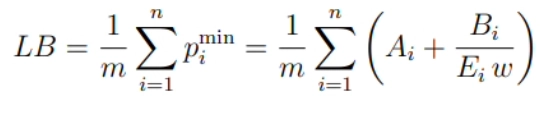

In [5]:
def lower_bound(inst: Instance) -> float:
    """
    Compute the basic lower bound (LB) from Eq. 6:

    LB = (1/m) * sum_i p_i(W)

    where p_i(W) = A_i + B_i/(E_i * W) is the minimum possible processing
    time for job i (achieved when all W workers are on the same machine).
    This is a relaxation — it ignores the feasibility constraint that each
    machine must receive at least one worker, so LB is often loose on small
    instances.
    """
  #p_i(W) = A_i + B_i/(E_i * W)  is the minimum p_i possible
    p_min = inst.A + inst.B / (inst.E * inst.W)
    return p_min.sum() / inst.m

In [6]:
#return (True, '') if feasible, (False, reason) otherwise
def is_feasible(inst: Instance,
                assignment: List[int],
                workers: List[int]) -> Tuple[bool, str]:
    """
    Check whether a (assignment, workers) pair satisfies all constraints.

    Returns
    -------
    (True, '')         if the solution is feasible.
    (False, reason)    if any constraint is violated, with a description.

    Checks: correct lengths, workers >= 1, sum(workers) == W,
            all machine indices in [0, m-1].
    """

    if len(assignment) != inst.n: return False, "wrong assignment length"
    if len(workers)    != inst.m: return False, "wrong workers length"
    if any(w < 1 for w in workers): return False, f"worker < 1: {workers}"
    if sum(workers) != inst.W: return False, f"workers sum {sum(workers)} != W={inst.W}"
    if any(k < 0 or k >= inst.m for k in assignment): return False, "invalid machine index"
    return True, ""

methods to print our solutions

In [7]:
def print_instance(inst: Instance) -> None:
    print(f"\n{'_'*55}")
    print(f"  Instance : {inst.name}  |  family={inst.family}  seed={inst.seed}")
    print(f"  n={inst.n} jobs,  m={inst.m} machines,  W={inst.W} workers")
    print(f"{'_'*55}")
    print(f"  {'Job':>4}  {'A':>8}  {'B':>8}  {'E':>8}  {'p_i(W)':>10}")
    print(f"{'-'*55}")
    for i in range(inst.n):
        print(f"  {i:>4}  {inst.A[i]:>8.2f}  {inst.B[i]:>8.2f}  "
              f"{inst.E[i]:>8.2f}  {inst.processing_time(i, inst.W):>10.4f}")
    print(f"{'-'*55}")
    print(f"  LB = {lower_bound(inst):.4f}")
    print(f"{'-'*55}\n")


def print_solution(inst: Instance, sol: Solution, label: str = "Solution") -> None:
    ok, msg = is_feasible(inst, sol.assignment, sol.workers)
    status = "FEASIBLE" if ok else f"INFEASIBLE ({msg})"
    lb = lower_bound(inst)
    gap = (sol.makespan / lb - 1) * 100 if lb > 0 else float("inf")
    print(f"\n{'_'*55}")
    print(f"  {label}  —  {status}")
    print(f"  Cmax = {sol.makespan:.4f}   LB = {lb:.4f}   gap = {gap:.1f}%")
    print(f"{'─'*55}")
    for k in range(inst.m):
        jobs_on_k = [i for i, mk in enumerate(sol.assignment) if mk == k]
        load = sum(inst.processing_time(i, sol.workers[k]) for i in jobs_on_k)
        print(f"  Machine {k}  workers={sol.workers[k]}  load={load:.4f}  "
              f"jobs={jobs_on_k or []}")
    print(f"{'_'*55}\n")


we run sanity checks after any change to the infrastructure cell

In [8]:
def run_sanity_checks():
    print("Running sanity checks: \n")

    #some small instances for the check
    inst = Instance(
        n=4, m=2, W=4,
        A=np.array([10., 20., 15.,  5.]),
        B=np.array([30., 40., 20., 10.]),
        E=np.array([ 1.,  1.,  1.,  1.]),
        name="I/P/4/2/4", family="manual", seed=0
    )

    #p_0(2) = 10 + 30/(1*2) = 25.0
    pt = inst.processing_time(0, 2)
    assert abs(pt - 25.0) < 1e-9
    print(f"processing_time(job=0, u=2) = {pt}")

    #machine 0: jobs 0,1 with 2 workers -> 25 + 40 = 65
    #machine 1: jobs 2,3 with 2 workers -> 25 + 10 = 35 -> Cmax = 65
    cmax = compute_makespan(inst, [0, 0, 1, 1], [2, 2])
    assert abs(cmax - 65.0) < 1e-9
    print(f"compute_makespan = {cmax}")

    #LB = (17.5 + 30 + 20 + 7.5) / 2 = 75 / 2 = 37.5
    lb = lower_bound(inst)
    assert abs(lb - 37.5) < 1e-9
    print(f"lower_bound = {lb}")

    assert cmax >= lb
    print(f"Cmax ({cmax}) >= LB ({lb})")

    assert inst.precompute_pt().shape == (inst.n, inst.W)
    print(f"precompute_pt shape = {inst.precompute_pt().shape}")

    #save / load round-trip
    save_instance(inst, "/tmp/test_inst.txt")
    loaded = load_instance("/tmp/test_inst.txt")
    assert loaded.n == inst.n and np.allclose(loaded.A, inst.A)
    print(f"save/load round-trip")

    #family H generation
    h = generate_instance(6, 3, 10, family="H", seed=0)
    assert h.n == 6 and h.B.min() >= 1 and h.E.min() >= 1
    print(f"generate_instance (Family H)")

    ok, _ = is_feasible(inst, [0,0,1,1], [2,2])
    assert ok
    ok2, _ = is_feasible(inst, [0,0,1,1], [3,3])   #sum=6 != W=4
    assert not ok2
    print(f"is_feasible checks")

    print("\nAll sanity checks passed!\n")

run_sanity_checks()


Running sanity checks: 

processing_time(job=0, u=2) = 25.0
compute_makespan = 65.0
lower_bound = 37.5
Cmax (65.0) >= LB (37.5)
precompute_pt shape = (4, 4)
save/load round-trip
generate_instance (Family H)
is_feasible checks

All sanity checks passed!



In [9]:
#generate and save both standard Family H benchmark sets
set_6  = generate_benchmark_set(n=6,  m=3, W=10, family="H", num_instances=100)
set_12 = generate_benchmark_set(n=12, m=3, W=10, family="H", num_instances=100)

save_instance_set(set_6,  "instances/H_6_3_10")
save_instance_set(set_12, "instances/H_12_3_10")

#reloading and verifying
loaded_6  = load_instance_set("instances/H_6_3_10")
loaded_12 = load_instance_set("instances/H_12_3_10")

assert len(loaded_6) == 100 and len(loaded_12) == 100
print("\nBenchmark sets ready.")


Saved 100 instances to 'instances/H_6_3_10/'
Saved 100 instances to 'instances/H_12_3_10/'
Loaded 100 instances from 'instances/H_6_3_10/'
Loaded 100 instances from 'instances/H_12_3_10/'

Benchmark sets ready.


In [10]:
#inspecting an instance
sample = loaded_6[0]
print_instance(sample)

#building a trivial round-robin solution just to test the printer
trivial_assignment = [i % sample.m for i in range(sample.n)]
trivial_workers    = [sample.W // sample.m] * sample.m
trivial_workers[0] += sample.W - sum(trivial_workers)   # fix remainder

trivial_sol = Solution(
    assignment=trivial_assignment,
    workers=trivial_workers,
    makespan=compute_makespan(sample, trivial_assignment, trivial_workers)
)
print_solution(sample, trivial_sol, label="Trivial round-robin")



_______________________________________________________
  Instance : I/P/6/3/10  |  family=H  seed=0
  n=6 jobs,  m=3 machines,  W=10 workers
_______________________________________________________
   Job         A         B         E      p_i(W)
-------------------------------------------------------
     0     85.00      8.00     50.00     85.0160
     1     63.00      2.00     61.00     63.0033
     2     51.00     18.00     97.00     51.0186
     3     26.00     81.00     73.00     26.1110
     4     30.00     65.00     63.00     30.1032
     5      4.00     91.00     54.00      4.1685
-------------------------------------------------------
  LB = 86.4735
-------------------------------------------------------


_______________________________________________________
  Trivial round-robin  —  FEASIBLE
  Cmax = 111.3174   LB = 86.4735   gap = 28.7%
───────────────────────────────────────────────────────
  Machine 0  workers=4  load=111.3174  jobs=[0, 3]
  Machine 1  workers=3  load

# Building RBR and MFR

Computing Ratio-Based Rule (RBR), which distributes workers proportionally to machine load

We first compute $C_k = \sum_{i \text{ on } k} p_i(1)$, then:
$$w_k = \left\lfloor W \cdot \frac{C_k}{\sum_l C_l} \right\rfloor$$
Last machine absorbs rounding remainder. Floor enforces $w_k \geq 1$.

In [11]:
def rbr(inst: Instance, assignment: List[int]) -> List[int]:
    """
    Ratio-Based Rule (RBR) Section 6.

    Distributes W workers proportionally to each machine's load when
    computed at 1 worker each:
        C_k = sum_{i on k} p_i(1)
        w_k = floor(W * C_k / sum_l C_l)

    The last machine absorbs the remainder to ensure sum(workers) == W.
    A repair step enforces w_k >= 1 throughout.

    Parameters
    ----------
    inst       : the instance
    assignment : current job-to-machine assignment

    Returns
    -------
    List[int] : worker counts for each machine, summing to W.
    """
    #loading at 1 worker per machine
    loads = [0.0] * inst.m
    for i, k in enumerate(assignment):
        loads[k] += inst.processing_time(i, 1)   # p_i(1) = A_i + B_i/E_i

    total_load = sum(loads)

    #edge case: no load at all (all-zero jobs), thus distribute evenly
    if total_load == 0:
        base = inst.W // inst.m
        workers = [base] * inst.m
        workers[0] += inst.W - sum(workers)
        return workers

    #proportional allocation, floor for machines 0..m-2
    workers = [max(1, int(inst.W * loads[k] / total_load))
               for k in range(inst.m - 1)]
    workers.append(max(1, inst.W - sum(workers)))

    #fixing rounding drift
    diff = sum(workers) - inst.W
    for _ in range(abs(diff)):
        if diff > 0:   #over-allocated: taking from the largest machine
            idx = max((k for k in range(inst.m) if workers[k] > 1),
                      key=lambda k: workers[k])
            workers[idx] -= 1
        else:          #under-allocated: give to the largest machine
            idx = max(range(inst.m), key=lambda k: workers[k])
            workers[idx] += 1
        diff = sum(workers) - inst.W

    assert sum(workers) == inst.W,    f"RBR sum error: {workers}"
    assert all(w >= 1 for w in workers), f"RBR zero-worker: {workers}"
    return workers

Computing Most-Loaded-Machine First Rule (MFR), where we implement greedy bottleneck reduction chasing unlike RBR which is purely proportional

In [12]:
#this function greedily assigns each remaining worker to the machine with highest load currently
def mfr(inst: Instance, assignment: List[int]) -> List[int]:
    """
    Most-Loaded-Machine First Rule (MFR) — Section 7.

    Starts with 1 worker per machine. Iteratively assigns the next
    available worker to the machine with the highest current load,
    recomputing that machine's load after each assignment. Repeats
    until all W workers are allocated.

    Unlike RBR (one-shot proportional), MFR is iterative and directly
    targets the bottleneck machine at each step.

    Parameters
    ----------
    inst       : the instance
    assignment : current job-to-machine assignment

    Returns
    -------
    List[int] : worker counts for each machine, summing to W.
    """
    workers = [1] * inst.m  #we first start with 1 worker per machine
    remaining = inst.W - inst.m    #workers still to place

    #helperfunction to recompute load of machine k given its current worker count
    def load_of(k: int) -> float:
        return sum(inst.processing_time(i, workers[k])
                   for i, mk in enumerate(assignment) if mk == k)

    #initially loads with 1 worker each
    loads = [load_of(k) for k in range(inst.m)]

    for _ in range(remaining):
        k_star = max(range(inst.m), key=lambda k: loads[k])
        workers[k_star] += 1
        loads[k_star] = load_of(k_star)    #update only the changed machine

    assert sum(workers) == inst.W,       f"MFR sum error: {workers}"
    assert all(w >= 1 for w in workers), f"MFR zero-worker: {workers}"
    return workers

# H1

Description: The algorithm proceeded in three stages. First, jobs were scheduled on the machines
using a chosen dispatching rule while ignoring worker allocation. Second, workers were
distributed across machines according to a predefined ratio. Finally, the makespan was
computed for the resulting job–worker assignment.
In the first stage, all jobs were sorted in non-increasing order of their processing
times. Scheduling then iteratively assigned the next job to the first machine that became
available, and this process continued until all jobs were placed. After completing the job
assignment, the RBR rule described in Subsection 6 was applied to allocate workers to
machines.

Goes through two stages:


1.  Stage 1 (job assignment):
        Sort jobs by p_i(1) in decreasing order  (aka LPT; Longest Processing Time).
        Assign each job to the machine with the
        smallest current cumulative load.
        By loading the longest jobs first,
        it tends to balance loads naturally.
2.  Stage 2 (worker allocation):
        Apply RBR on the resulting assignment



In [13]:
def h1(inst: Instance) -> Solution:
    """
    H1: LPT Dispatching + RBR

    Stage 1 (job assignment):
        Sort jobs by p_i(1) in DECREASING order (Longest Processing Time).
        Assign each job to the least-loaded machine (list scheduling).

    Stage 2 (worker allocation):
        Apply RBR to the resulting assignment.

    LPT provides a proven (4/3 - 1/(3m)) approximation for classic P||Cmax.
    By loading heavy jobs first, it naturally balances machine loads before
    smaller jobs fill remaining capacity.

    Returns
    -------
    Solution with assignment, workers, and makespan filled in.
    """
    #stage 1: LPT list scheduling (using p_i(1) as proxy for job length)
    p_base = [inst.processing_time(i, 1) for i in range(inst.n)]
    order = sorted(range(inst.n), key=lambda i: p_base[i], reverse=True)

    loads = [0.0] * inst.m
    assignment = [0] * inst.n
    for i in order:
        k = min(range(inst.m), key=lambda k: loads[k])
        assignment[i] = k
        loads[k] += p_base[i]

    #stage 2: RBR worker allocation
    workers = rbr(inst, assignment)
    makespan = compute_makespan(inst, assignment, workers)
    return Solution(assignment=assignment, workers=workers, makespan=makespan)

# H2

Description: First, all jobs were sorted in non-decreasing order of their processing times. Then, the
first job was assigned to the first machine, and each subsequent job was scheduled on
the currently earliest available machine. This procedure was repeated until all jobs were
assigned. After completing the job assignment, the RBR rule described in Subsection 6
was applied to allocate workers to machines.

Note: this heuristic is similar to what I implemented in h1, but the sorting of jobs is done in increasing order of p_i(1) (aka SPT; Shortest Processing Time)

SPT minimises average flow time in single-machine settings, but for
makespan on parallel machines it tends to create imbalance: long jobs
land on already-loaded machines late in the sequence.
As a result H2 typically performs worse than H1 on this objective,
but it serves as a useful contrast baseline.

In [14]:
def h2(inst: Instance) -> Solution:
    """
    H2: SPT Dispatching + RBR

    Same two-stage structure as H1 but sorts jobs in INCREASING order of
    p_i(1) (Shortest Processing Time). SPT is optimal for minimising average
    flow time on a single machine but performs poorly for makespan on parallel
    machines — long jobs land on already-loaded machines late in the sequence.

    Serves as a contrast baseline to demonstrate the cost of choosing the
    wrong dispatching rule.

    Returns
    -------
    Solution with assignment, workers, and makespan filled in.
    """
    p_base = [inst.processing_time(i, 1) for i in range(inst.n)]
    order = sorted(range(inst.n), key=lambda i: p_base[i])   #ascending

    loads = [0.0] * inst.m
    assignment = [0] * inst.n
    for i in order:
        k = min(range(inst.m), key=lambda k: loads[k])
        assignment[i] = k
        loads[k] += p_base[i]

    workers = rbr(inst, assignment)
    makespan = compute_makespan(inst, assignment, workers)
    return Solution(assignment=assignment, workers=workers, makespan=makespan)

# Results and Tests of H1 and H2

In [15]:
def test_rbr():
    #verifying RBR against a hand-calculated example
    print("--- RBR test ---")
    #n=4, m=2, W=6, all E=1 so p_i(u) = A+B/u
    inst = Instance(
        n=4, m=2, W=6,
        A=np.array([10., 20., 30.,  5.]),
        B=np.array([10., 20., 30.,  5.]),
        E=np.array([ 1.,  1.,  1.,  1.]),
        name="test", family="manual", seed=0
    )
    assignment = [0, 0, 1, 1]
    #loads at 1 worker:
    #machine 0: (10+10) + (20+20) = 60
    #machine 1: (30+30) + (5+5)   = 70   total = 130
    #workers[0] = floor(6 * 60/130) = floor(2.769) = 2
    #workers[1] = 6 - 2 = 4
    w = rbr(inst, assignment)
    assert w == [2, 4], f"Expected [2, 4], got {w}"
    ok, msg = is_feasible(inst, assignment, w)
    assert ok, msg
    print(f"workers = {w}  (expected [2, 4])")


def test_mfr():
    #verifying MFR produces a feasible allocation
    print("--- MFR test ---")
    inst = Instance(
        n=4, m=2, W=6,
        A=np.array([10., 20., 30.,  5.]),
        B=np.array([10., 20., 30.,  5.]),
        E=np.array([ 1.,  1.,  1.,  1.]),
        name="test", family="manual", seed=0
    )
    assignment = [0, 0, 1, 1]
    w = mfr(inst, assignment)
    ok, msg = is_feasible(inst, assignment, w)
    assert ok, msg
    cmax = compute_makespan(inst, assignment, w)
    print(f"workers = {w}   Cmax = {cmax:.4f}")


def test_h1_h2_seed0():
    #check H1 and H2 on our reference instance
    print("--- H1 / H2 on I/P/6/3/10 seed=0 ---")
    inst = generate_instance(6, 3, 10, family="H", seed=0)
    lb   = lower_bound(inst)

    sol1 = h1(inst)
    sol2 = h2(inst)

    ok1, m1 = is_feasible(inst, sol1.assignment, sol1.workers)
    ok2, m2 = is_feasible(inst, sol2.assignment, sol2.workers)
    assert ok1, f"H1 infeasible: {m1}"
    assert ok2, f"H2 infeasible: {m2}"

    g1 = (sol1.makespan / lb - 1) * 100
    g2 = (sol2.makespan / lb - 1) * 100

    print(f"  LB   = {lb:.4f}")
    print(f"  H1   Cmax = {sol1.makespan:.4f}   gap = {g1:.1f}%   workers = {sol1.workers}")
    print(f"  H2   Cmax = {sol2.makespan:.4f}   gap = {g2:.1f}%   workers = {sol2.workers}")
    print(f"  (Trivial round-robin from Day 1: Cmax=111.3174, gap=28.7%)")

    # H1 should beat trivial; H2 may not (SPT is known to be weaker for makespan)
    assert sol1.makespan < 111.4, f"H1 should beat trivial (111.3), got {sol1.makespan:.4f}"
    print(f"H1 beats trivial round-robin")
    if sol2.makespan >= 111.4:
        print(f"H2 is worse than trivial on this instance, expected for SPT on makespan")
    else:
        print(f"H2 also beats trivial on this instance")


def test_bulk_feasibility():
    #all 200 Family H instances, both heuristics
    #feasibility + Cmax consistency
    print("--- Bulk feasibility (200 instances × 2 heuristics) ---")
    passed = 0
    for seed in range(100):
        for n, m, W in [(6,3,10), (12,3,10)]:
            inst = generate_instance(n, m, W, family="H", seed=seed)
            for name, sol in [("H1", h1(inst)), ("H2", h2(inst))]:
                ok, msg = is_feasible(inst, sol.assignment, sol.workers)
                assert ok, f"{name} n={n} seed={seed}: {msg}"
                recomputed = compute_makespan(inst, sol.assignment, sol.workers)
                assert abs(recomputed - sol.makespan) < 1e-9,                     f"{name} makespan mismatch on n={n} seed={seed}"
                passed += 1
    print(f"{passed} / {passed} feasible and Cmax verified")


def benchmark_summary():
    #average gaps over Family H benchmark sets
    print("\n--- Benchmark summary ---")
    for n, m, W in [(6,3,10), (12,3,10)]:
        h1_gaps, h2_gaps, h1_wins, h2_wins = [], [], 0, 0
        for seed in range(100):
            inst = generate_instance(n, m, W, family="H", seed=seed)
            lb = lower_bound(inst)
            c1 = h1(inst).makespan
            c2 = h2(inst).makespan
            h1_gaps.append((c1/lb-1)*100)
            h2_gaps.append((c2/lb-1)*100)
            if c1 < c2: h1_wins += 1
            elif c2 < c1: h2_wins += 1
        print(f"\n  I/P/{n}/{m}/{W} (100 instances):")
        for alg, gaps, wins in [("H1", h1_gaps, h1_wins), ("H2", h2_gaps, h2_wins)]:
            print(f"    {alg}:  avg gap={np.mean(gaps):.1f}%  "
                  f"min={np.min(gaps):.1f}%  max={np.max(gaps):.1f}%  wins={wins}/100")


#now we run all tests
test_mfr()
test_h1_h2_seed0()
test_bulk_feasibility()
benchmark_summary()
print("\nAll tests passed!")

--- MFR test ---
workers = [2, 4]   Cmax = 45.0000
--- H1 / H2 on I/P/6/3/10 seed=0 ---
  LB   = 86.4735
  H1   Cmax = 89.3808   gap = 3.4%   workers = [3, 3, 4]
  H2   Cmax = 115.2383   gap = 33.3%   workers = [2, 3, 5]
  (Trivial round-robin from Day 1: Cmax=111.3174, gap=28.7%)
H1 beats trivial round-robin
H2 is worse than trivial on this instance, expected for SPT on makespan
--- Bulk feasibility (200 instances × 2 heuristics) ---
400 / 400 feasible and Cmax verified

--- Benchmark summary ---

  I/P/6/3/10 (100 instances):
    H1:  avg gap=13.3%  min=0.9%  max=87.5%  wins=96/100
    H2:  avg gap=31.1%  min=5.1%  max=111.2%  wins=3/100

  I/P/12/3/10 (100 instances):
    H1:  avg gap=6.0%  min=0.8%  max=27.0%  wins=88/100
    H2:  avg gap=15.8%  min=4.9%  max=35.9%  wins=10/100

All tests passed!


tests on specific solutions per seed change

In [16]:
seed = 0
inst = generate_instance(6, 3, 10, family="H", seed=seed)
lb   = lower_bound(inst)

sol_h1 = h1(inst)
sol_h2 = h2(inst)

print_instance(inst)
print_solution(inst, sol_h1, label="H1 (LPT + RBR)")
print_solution(inst, sol_h2, label="H2 (SPT + RBR)")


_______________________________________________________
  Instance : I/P/6/3/10  |  family=H  seed=0
  n=6 jobs,  m=3 machines,  W=10 workers
_______________________________________________________
   Job         A         B         E      p_i(W)
-------------------------------------------------------
     0     85.00      8.00     50.00     85.0160
     1     63.00      2.00     61.00     63.0033
     2     51.00     18.00     97.00     51.0186
     3     26.00     81.00     73.00     26.1110
     4     30.00     65.00     63.00     30.1032
     5      4.00     91.00     54.00      4.1685
-------------------------------------------------------
  LB = 86.4735
-------------------------------------------------------


_______________________________________________________
  H1 (LPT + RBR)  —  FEASIBLE
  Cmax = 89.3808   LB = 86.4735   gap = 3.4%
───────────────────────────────────────────────────────
  Machine 0  workers=3  load=85.0533  jobs=[0]
  Machine 1  workers=3  load=89.3808  j

# H3

In [17]:
def h3(inst) -> "Solution":
    """

    Stage 1  – job assignment
    ─────────────────────────
    • Compute LB (Equation 6).
    • Sort jobs in NON-INCREASING order of p_i(1).
    • Fill machine 0 with jobs as long as its cumulative load ≤ LB,
      then move to machine 1, and so on.
    • Collect remaining (overflow) jobs into RJ.

    Stage 2  – worker allocation
    ────────────────────────────
    • Apply MFR on the current (partial) assignment.

    Stage 3  – schedule overflow jobs
    ───────────────────────────────────
    • Assign each job in RJ to the most-available machine
      (smallest current load using the MFR workers).
    """
    lb = lower_bound(inst)

    # p_i(1) proxy for job length
    p_base = [inst.processing_time(i, 1) for i in range(inst.n)]

    # Non-increasing order (LPT)
    order = sorted(range(inst.n), key=lambda i: p_base[i], reverse=True)

    assignment = [-1] * inst.n
    loads = [0.0] * inst.m
    rj = []  # overflow jobs

    machine = 0
    for i in order:
        if machine >= inst.m:
            # All machines have exceeded LB; overflow
            rj.append(i)
            continue

        if loads[machine] + p_base[i] <= lb + 1e-9:
            assignment[i] = machine
            loads[machine] += p_base[i]
        else:
            # Current machine is full; try the next one
            machine += 1
            if machine >= inst.m:
                rj.append(i)
            elif loads[machine] + p_base[i] <= lb + 1e-9:
                assignment[i] = machine
                loads[machine] += p_base[i]
            else:
                rj.append(i)

    # Any job still unassigned (assignment == -1) goes to RJ
    for i in range(inst.n):
        if assignment[i] == -1:
            rj.append(i)

    # Stage 2: MFR with current partial assignment
    # Temporarily assign overflow jobs to machine 0 so mfr() works on all jobs
    temp_assignment = assignment[:]
    for i in rj:
        temp_assignment[i] = 0           # placeholder — will be re-assigned

    workers = mfr(inst, temp_assignment)

    # Stage 3: schedule RJ on most-available machine using the MFR workers
    # Recompute loads for machines that already have jobs
    real_loads = [0.0] * inst.m
    for i in range(inst.n):
        if i not in rj:
            real_loads[assignment[i]] += inst.processing_time(i, workers[assignment[i]])

    for i in rj:
        k = min(range(inst.m), key=lambda k: real_loads[k])
        assignment[i] = k
        real_loads[k] += inst.processing_time(i, workers[k])

    makespan = compute_makespan(inst, assignment, workers)
    return Solution(assignment=assignment, workers=workers, makespan=makespan)


# H4

In [18]:
def h4(inst) -> "Solution":
    """
    Identical to H3, except jobs are sorted in NON-DECREASING order of p_i(1)
    (SPT instead of LPT).
    """
    lb = lower_bound(inst)

    p_base = [inst.processing_time(i, 1) for i in range(inst.n)]

    # Non-decreasing order (SPT)
    order = sorted(range(inst.n), key=lambda i: p_base[i])

    assignment = [-1] * inst.n
    loads = [0.0] * inst.m
    rj = []

    machine = 0
    for i in order:
        if machine >= inst.m:
            rj.append(i)
            continue

        if loads[machine] + p_base[i] <= lb + 1e-9:
            assignment[i] = machine
            loads[machine] += p_base[i]
        else:
            machine += 1
            if machine >= inst.m:
                rj.append(i)
            elif loads[machine] + p_base[i] <= lb + 1e-9:
                assignment[i] = machine
                loads[machine] += p_base[i]
            else:
                rj.append(i)

    for i in range(inst.n):
        if assignment[i] == -1:
            rj.append(i)

    # Stage 2: MFR worker allocation on partial assignment
    temp_assignment = assignment[:]
    for i in rj:
        temp_assignment[i] = 0

    workers = mfr(inst, temp_assignment)

    # Stage 3: schedule RJ on most-available machine
    real_loads = [0.0] * inst.m
    for i in range(inst.n):
        if i not in rj:
            real_loads[assignment[i]] += inst.processing_time(i, workers[assignment[i]])

    for i in rj:
        k = min(range(inst.m), key=lambda k: real_loads[k])
        assignment[i] = k
        real_loads[k] += inst.processing_time(i, workers[k])

    makespan = compute_makespan(inst, assignment, workers)
    return Solution(assignment=assignment, workers=workers, makespan=makespan)


Genetic Algorithm (GA)

In [19]:
import math
import random
import copy
import numpy as np
from typing import List, Tuple

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#  Genetic Algorithm
# ─────────────────────────────────────────────────────────────────────────────

# ── Chromosome representation ────────────────────────────────────────────────
#
#  A chromosome is a tuple  (pi, W)  where:
#    pi  – list[int] of length n  : job permutation (priority list)
#    W   – list[int] of length m  : worker counts, sum == inst.W, each >= 1
#
# ── Decoding / fitness ───────────────────────────────────────────────────────
def _decode(inst, pi: List[int], workers: List[int]) -> float:
    """
    List-scheduling decoder: assign jobs in order pi to the most-available machine.
    Returns Cmax.
    """
    loads = [0.0] * inst.m
    assignment = [0] * inst.n
    for i in pi:
        k = min(range(inst.m), key=lambda k: loads[k])
        assignment[i] = k
        loads[k] += inst.processing_time(i, workers[k])
    return max(loads), assignment


def _fitness(inst, pi: List[int], workers: List[int]) -> Tuple[float, List[int]]:
    cmax, assignment = _decode(inst, pi, workers)
    return cmax, assignment


# ── Feasibility repair for worker vector ─────────────────────────────────────
def _repair_workers(workers: List[int], W: int, m: int,
                    rng: np.random.Generator) -> List[int]:
    """
    Enforce  sum(workers) == W  and  workers[k] >= 1  for all k.
    Algorithm 2, Step 16 / Section 17.7.
    """
    w = workers[:]
    # Step 1: enforce lower bounds
    for k in range(m):
        if w[k] < 1:
            w[k] = 1
    # Step 2: compute delta
    delta = sum(w) - W
    indices = list(range(m))
    if delta > 0:
        # Over-allocated: randomly remove from machines with w[k] > 1
        for _ in range(abs(delta)):
            eligible = [k for k in indices if w[k] > 1]
            if not eligible:
                break
            k = int(rng.choice(eligible))
            w[k] -= 1
    elif delta < 0:
        # Under-allocated: randomly add
        for _ in range(abs(delta)):
            k = int(rng.choice(indices))
            w[k] += 1
    return w


# ── Crossover operators ───────────────────────────────────────────────────────
def _ox_crossover(pi1: List[int], pi2: List[int],
                  rng: np.random.Generator) -> List[int]:
    """
    Order-Based Crossover (OX) for job permutation.
    Preserves job uniqueness .
    """
    n = len(pi1)
    a, b = sorted(rng.choice(n, size=2, replace=False))
    child = [-1] * n
    # Copy segment from parent 1
    child[a:b + 1] = pi1[a:b + 1]
    # Fill remaining positions with parent 2's order
    fill_vals = [x for x in pi2 if x not in child[a:b + 1]]
    idx = 0
    for pos in list(range(b + 1, n)) + list(range(0, a)):
        child[pos] = fill_vals[idx]
        idx += 1
    return child


def _one_point_worker_crossover(w1: List[int], w2: List[int],
                                rng: np.random.Generator) -> List[int]:
    """
    One-point crossover on worker vectors .
    """
    m = len(w1)
    cut = int(rng.integers(1, m))
    return w1[:cut] + w2[cut:]


# ── Mutation operators ────────────────────────────────────────────────────────
def _mutate_permutation(pi: List[int], rng: np.random.Generator) -> List[int]:
    """Swap two random positions in the job permutation ."""
    p = pi[:]
    n = len(p)
    i, j = rng.choice(n, size=2, replace=False)
    p[i], p[j] = p[j], p[i]
    return p


def _mutate_workers(workers: List[int], W: int,
                    rng: np.random.Generator) -> List[int]:
    """
    Transfer one worker from machine a to machine b .
    Preserves feasibility.
    """
    w = workers[:]
    m = len(w)
    donors = [k for k in range(m) if w[k] > 1]
    if not donors:
        return w
    a = int(rng.choice(donors))
    others = [k for k in range(m) if k != a]
    b = int(rng.choice(others))
    w[a] -= 1
    w[b] += 1
    return w


# ── Tournament selection ──────────────────────────────────────────────────────
def _tournament_select(population, fitnesses: List[float],
                       q: int, rng: np.random.Generator):
    """Return the best individual among q randomly sampled candidates."""
    candidates = rng.choice(len(population), size=q, replace=False)
    best_idx = int(min(candidates, key=lambda i: fitnesses[i]))
    return copy.deepcopy(population[best_idx])


# ── Initial population ────────────────────────────────────────────────────────
def _init_population(inst, pop_size: int,
                     rng: np.random.Generator) -> List[Tuple[List[int], List[int]]]:
    """
    Mix of heuristic-based and randomized individuals .
    """
    population = []

    # 1. LPT + RBR
    s = h3(inst)
    pi_lpt = sorted(range(inst.n),
                    key=lambda i: inst.processing_time(i, 1), reverse=True)
    population.append((pi_lpt, s.workers[:]))

    # 2. LPT + MFR
    workers_mfr = mfr(inst, s.assignment)
    population.append((pi_lpt[:], workers_mfr))

    # 3. SPT + RBR
    s2 = h4(inst)
    pi_spt = sorted(range(inst.n),
                    key=lambda i: inst.processing_time(i, 1))
    population.append((pi_spt, s2.workers[:]))

    # 4. H3 / H4 permutations
    s3 = h3(inst)
    population.append((pi_lpt[:], s3.workers[:]))
    s4 = h4(inst)
    population.append((pi_spt[:], s4.workers[:]))

    # Fill the rest with randomized individuals
    while len(population) < pop_size:
        pi_rand = list(rng.permutation(inst.n))
        # Random feasible worker vector
        base = [1] * inst.m
        extra = inst.W - inst.m
        for _ in range(extra):
            k = int(rng.integers(inst.m))
            base[k] += 1
        population.append((pi_rand, base))

    return population[:pop_size]


# ── Main GA ───────────────────────────────────────────────────────────────────
def genetic_algorithm(
    inst,
    pop_size:    int   = 50,       # population size P
    n_gen:       int   = 200,      # maximum generations G_max
    elitism:     int   = 2,        # elite individuals copied each generation E
    tournament_q: int  = 3,        # tournament size q
    p_crossover: float = 0.85,     # crossover probability p_c
    p_mutate:    float = 0.15,     # mutation probability p_mut
    stall_limit: int   = 40,       # G_stall – stop if no improvement for this many gens
    seed:        int   = 42,
    verbose:     bool  = False,
) -> Tuple["Solution", List[float]]:
    """
    Genetic Algorithm for P||Cmax with worker assignment (Algorithm 2 / Section 17).

    Parameters
    ----------
    inst        : Instance
    pop_size    : population size
    n_gen       : maximum generations
    elitism     : number of elite individuals transferred each generation
    tournament_q: tournament size for parent selection
    p_crossover : crossover probability (otherwise copy best parent)
    p_mutate    : mutation probability
    stall_limit : stop after this many generations without improvement
    seed        : RNG seed
    verbose     : print progress every 20 generations

    Returns
    -------
    best_solution : Solution
    history       : list of best Cmax after each generation
    """
    rng = np.random.default_rng(seed)

    # ── Step 1: Initialise population ────────────────────────────────────────
    population = _init_population(inst, pop_size, rng)

    # ── Evaluate initial population ──────────────────────────────────────────
    fitnesses = []
    assignments_cache = []
    for (pi, w) in population:
        cmax, asgn = _fitness(inst, pi, w)
        fitnesses.append(cmax)
        assignments_cache.append(asgn)

    best_idx  = int(np.argmin(fitnesses))
    best_cmax = fitnesses[best_idx]
    best_pi   = population[best_idx][0][:]
    best_w    = population[best_idx][1][:]
    best_asgn = assignments_cache[best_idx][:]

    history    = [best_cmax]
    stall_cnt  = 0

    # ── Generational loop ─────────────────────────────────────────────────────
    for gen in range(n_gen):
        # ── Elitism: keep top E individuals ──────────────────────────────────
        elite_indices = sorted(range(pop_size), key=lambda i: fitnesses[i])[:elitism]
        new_pop  = [copy.deepcopy(population[i]) for i in elite_indices]
        new_fit  = [fitnesses[i] for i in elite_indices]
        new_asgn = [assignments_cache[i][:] for i in elite_indices]

        # ── Fill rest with offspring ──────────────────────────────────────────
        while len(new_pop) < pop_size:
            # Parent selection
            p1 = _tournament_select(population, fitnesses, tournament_q, rng)
            p2 = _tournament_select(population, fitnesses, tournament_q, rng)
            pi1, w1 = p1
            pi2, w2 = p2

            # Crossover
            if rng.random() < p_crossover:
                child_pi = _ox_crossover(pi1, pi2, rng)
                child_w  = _one_point_worker_crossover(w1, w2, rng)
            else:
                # Copy best parent
                if fitnesses[population.index(p1)] <= fitnesses[population.index(p2)]:
                    child_pi, child_w = pi1[:], w1[:]
                else:
                    child_pi, child_w = pi2[:], w2[:]

            # Mutation
            if rng.random() < p_mutate:
                child_pi = _mutate_permutation(child_pi, rng)
            if rng.random() < p_mutate:
                child_w = _mutate_workers(child_w, inst.W, rng)

            # Feasibility repair on worker vector
            child_w = _repair_workers(child_w, inst.W, inst.m, rng)

            # refine workers with MFR after repair
            cmax_child, asgn_child = _fitness(inst, child_pi, child_w)

            new_pop.append((child_pi, child_w))
            new_fit.append(cmax_child)
            new_asgn.append(asgn_child)

        population         = new_pop
        fitnesses          = new_fit
        assignments_cache  = new_asgn

        # ── Update best ───────────────────────────────────────────────────────
        gen_best_idx = int(np.argmin(fitnesses))
        gen_best     = fitnesses[gen_best_idx]

        if gen_best < best_cmax - 1e-9:
            best_cmax = gen_best
            best_pi   = population[gen_best_idx][0][:]
            best_w    = population[gen_best_idx][1][:]
            best_asgn = assignments_cache[gen_best_idx][:]
            stall_cnt = 0
        else:
            stall_cnt += 1

        history.append(best_cmax)

        if verbose and (gen + 1) % 20 == 0:
            lb  = lower_bound(inst)
            gap = (best_cmax / lb - 1) * 100
            print(f"Gen {gen+1:>4}/{n_gen}  best_Cmax={best_cmax:.4f}  "
                  f"gap={gap:.2f}%  stall={stall_cnt}")

        # ── Early stopping ────────────────────────────────────────────────────
        if stall_cnt >= stall_limit:
            if verbose:
                print(f"Early stop at generation {gen+1} (stall={stall_cnt})")
            break

    # Build final Solution object using the actual assignment from the best chromosome
    best_sol = Solution(
        assignment=best_asgn,
        workers=best_w,
        makespan=compute_makespan(inst, best_asgn, best_w)
    )
    return best_sol, history


plot

Gen   20/200  best_Cmax=196.1682  gap=0.60%  stall=9
Gen   40/200  best_Cmax=196.1682  gap=0.60%  stall=29
Gen   60/200  best_Cmax=196.1682  gap=0.60%  stall=49
Early stop at generation 61 (stall=50)

_______________________________________________________
  Instance : I/P/12/3/10  |  family=H  seed=5
  n=12 jobs,  m=3 machines,  W=10 workers
_______________________________________________________
   Job         A         B         E      p_i(W)
-------------------------------------------------------
     0     67.00     57.00     28.00     67.2036
     1     80.00     41.00     44.00     80.0932
     2      2.00     13.00     27.00      2.0481
     3     80.00      5.00     97.00     80.0052
     4     46.00      1.00     18.00     46.0056
     5     51.00      5.00     89.00     51.0056
     6     63.00     15.00     79.00     63.0190
     7     28.00     99.00     84.00     28.1179
     8     97.00     19.00     12.00     97.1583
     9      5.00     65.00     39.00      5.1667
    

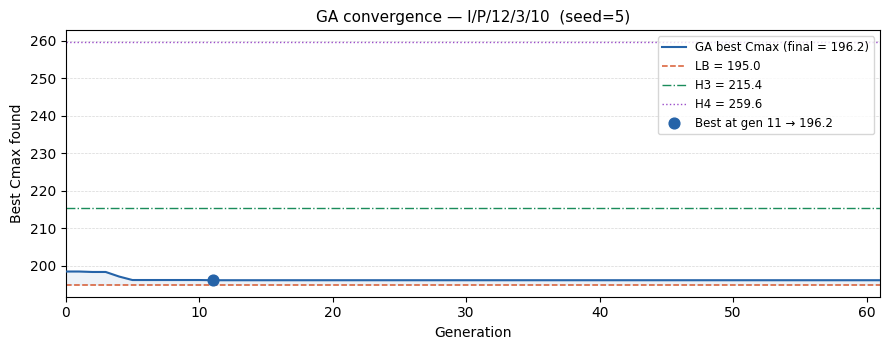


Final gap vs LB  : 0.60%
H3 gap vs LB     : 10.45%
H4 gap vs LB     : 33.11%


In [21]:
import matplotlib.pyplot as plt
import numpy as np

inst = generate_instance(12, 3, 10, family="H", seed=5)
lb   = lower_bound(inst)

# ── Run H3, H4, GA ───────────────────────────────────────────────────────────
sol_h3 = h3(inst)
sol_h4 = h4(inst)

sol_ga, ga_history = genetic_algorithm(
    inst,
    pop_size    = 50,
    n_gen       = 200,
    stall_limit = 50,
    seed        = 42,
    verbose     = True,
)

# ── Print solutions ───────────────────────────────────────────────────────────
print_instance(inst)
print_solution(inst, sol_h3, label="H3 (LB-guided LPT + MFR)")
print_solution(inst, sol_h4, label="H4 (LB-guided SPT + MFR)")
print_solution(inst, sol_ga, label="GA  (after search)")

# ── Convergence plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.6))

# GA convergence line
ax.plot(ga_history, linewidth=1.5, color="#2563A8",
        label=f"GA best Cmax (final = {sol_ga.makespan:.1f})", zorder=3)

# Reference horizontals
ax.axhline(lb,
           color="#D85A30", linestyle="--", linewidth=1.1,
           label=f"LB = {lb:.1f}")
ax.axhline(sol_h3.makespan,
           color="#1A8C5B", linestyle="-.", linewidth=1.0,
           label=f"H3 = {sol_h3.makespan:.1f}")
ax.axhline(sol_h4.makespan,
           color="#9B4DCA", linestyle=":",  linewidth=1.0,
           label=f"H4 = {sol_h4.makespan:.1f}")

# Shade the gap between GA and LB
ax.fill_between(range(len(ga_history)), ga_history, lb,
                alpha=0.08, color="#2563A8")

# Mark best point
best_gen = int(np.argmin(ga_history))
ax.scatter([best_gen], [min(ga_history)],
           color="#2563A8", s=60, zorder=5,
           label=f"Best at gen {best_gen} → {min(ga_history):.1f}")

ax.set_xlabel("Generation", fontsize=10)
ax.set_ylabel("Best Cmax found", fontsize=10)
ax.set_title("GA convergence — I/P/12/3/10  (seed=5)", fontsize=11)
ax.legend(fontsize=8.5, loc="upper right")
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_xlim(0, len(ga_history) - 1)

plt.tight_layout()
plt.savefig("ga_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nFinal gap vs LB  : {(sol_ga.makespan / lb - 1) * 100:.2f}%")
print(f"H3 gap vs LB     : {(sol_h3.makespan / lb - 1) * 100:.2f}%")
print(f"H4 gap vs LB     : {(sol_h4.makespan / lb - 1) * 100:.2f}%")

Testing

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
#  Tests
# ─────────────────────────────────────────────────────────────────────────────
def test_h3_h4_feasibility():
    print("--- H3 / H4 feasibility (200 instances) ---")
    passed = 0
    for seed in range(100):
        for n, m, W in [(6, 3, 10), (12, 3, 10)]:
            inst = generate_instance(n, m, W, family="H", seed=seed)
            for name, sol in [("H3", h3(inst)), ("H4", h4(inst))]:
                ok, msg = is_feasible(inst, sol.assignment, sol.workers)
                assert ok, f"{name} n={n} seed={seed}: {msg}"
                rc = compute_makespan(inst, sol.assignment, sol.workers)
                assert abs(rc - sol.makespan) < 1e-9, f"{name} makespan mismatch"
                passed += 1
    print(f"{passed}/{passed} feasible and Cmax verified")




def test_ga_feasibility():
    print("\n--- GA feasibility (200 instances) ---")
    passed = 0
    for seed in range(100):
        for n, m, W in [(6, 3, 10), (12, 3, 10)]:
            inst = generate_instance(n, m, W, family="H", seed=seed)
            sol, _ = genetic_algorithm(inst, pop_size=100, n_gen=30,
                                       stall_limit=15, seed=seed)
            ok, msg = is_feasible(inst, sol.assignment, sol.workers)
            assert ok, f"GA infeasible n={n} seed={seed}: {msg}"
            rc = compute_makespan(inst, sol.assignment, sol.workers)
            assert abs(rc - sol.makespan) < 1e-9, "GA makespan mismatch"
            passed += 1
    print(f"{passed}/{passed} feasible and Cmax verified")




def benchmark_h3_h4_ga():
    """Average gaps over Family H benchmark sets for H3, H4, GA vs H1, H2."""
    print("\n--- Benchmark summary:  H3, H4, GA ---")
    for n, m, W in [(6, 3, 10), (12, 3, 10)]:
        alg_gaps  = {a: [] for a in ["H3", "H4", "GA"]}
        alg_wins  = {a: 0  for a in ["H3", "H4", "GA"]}
        for seed in range(100):
            inst = generate_instance(n, m, W, family="H", seed=seed)
            lb   = lower_bound(inst)
            results = {

                "H3": h3(inst).makespan,
                "H4": h4(inst).makespan,
                "GA": genetic_algorithm(inst, pop_size=30, n_gen=80,
                                        stall_limit=25, seed=seed)[0].makespan,
            }
            best_c = min(results.values())
            for alg, c in results.items():
                alg_gaps[alg].append((c / lb - 1) * 100)
                if abs(c - best_c) < 1e-9:
                    alg_wins[alg] += 1

        print(f"\n  I/P/{n}/{m}/{W} (100 instances):")
        print(f"  {'Alg':<6}  {'avg gap':>8}  {'min':>6}  {'max':>6}  {'wins':>6}")
        print(f"  {'─'*6}  {'─'*8}  {'─'*6}  {'─'*6}  {'─'*6}")
        for alg in ["H3", "H4", "GA"]:
            g = alg_gaps[alg]
            print(f"  {alg:<6}  {np.mean(g):>7.2f}%  "
                  f"{np.min(g):>5.2f}%  {np.max(g):>5.2f}%  "
                  f"{alg_wins[alg]:>5}/100")


In [23]:
test_h3_h4_feasibility()
test_ga_feasibility()
benchmark_h3_h4_ga()




--- H3 / H4 feasibility (200 instances) ---
400/400 feasible and Cmax verified

--- GA feasibility (200 instances) ---
200/200 feasible and Cmax verified

--- Benchmark summary:  H3, H4, GA ---

  I/P/6/3/10 (100 instances):
  Alg      avg gap     min     max    wins
  ──────  ────────  ──────  ──────  ──────
  H3        39.17%   3.97%  160.26%      1/100
  H4        59.27%  23.25%  160.26%      0/100
  GA        11.61%   0.75%  87.42%    100/100

  I/P/12/3/10 (100 instances):
  Alg      avg gap     min     max    wins
  ──────  ────────  ──────  ──────  ──────
  H3        16.68%   1.60%  49.46%      0/100
  H4        34.48%  16.40%  68.55%      0/100
  GA         1.23%   0.32%   3.50%    100/100


# Simulated Annealing (SA)

before SA, we find T0 using:
$$T_0 = -\frac{\overline{\Delta}}{\ln(p_0)}$$
where $p_0 = 0.80$ (target acceptance rate) and $\overline{\Delta}$ is
the mean worsening delta. This adapts $T_0$ to each instance automatically.

Method used is Standard SA Calibration. Steps:


1.   sample n_samples random neighbours
2.   collect all delta = new_Cmax - curr_Cmax,  where delta > 0
3.   solve  exp(-mean_delta / T0) = target  for T0:
             T0 = -mean_delta / ln(target)



In [24]:
#temprature calibration to set T0
def _calibrate_T0(inst: Instance,
                  assignment: List[int],
                  workers: List[int],
                  target_acceptance: float = 0.80,
                  n_samples: int = 200,
                  rng=None) -> float:
    if rng is None:
        rng = np.random.default_rng(42)

    deltas = []
    curr_cmax = compute_makespan(inst, assignment, workers)

    for _ in range(n_samples):
        a2 = assignment[:]
        w2 = workers[:]
        move = rng.integers(3)

        if move == 0:                                  #job-move
            i = int(rng.integers(inst.n))
            k_new = int(rng.integers(inst.m - 1))
            if k_new >= a2[i]: k_new += 1
            a2[i] = k_new
            w2 = rbr(inst, a2)
        elif move == 1 and inst.n > 1:                 #job-swap
            i, j = rng.choice(inst.n, size=2, replace=False)
            if a2[i] != a2[j]:
                a2[i], a2[j] = a2[j], a2[i]
        else:                                          #worker-transfer
            donors = [k for k in range(inst.m) if w2[k] > 1]
            if donors:
                k_from = int(donors[rng.integers(len(donors))])
                k_to   = int(rng.integers(inst.m - 1))
                if k_to >= k_from: k_to += 1
                w2[k_from] -= 1
                w2[k_to]   += 1

        ok, _ = is_feasible(inst, a2, w2)
        if not ok: continue
        delta = compute_makespan(inst, a2, w2) - curr_cmax
        if delta > 0:
            deltas.append(delta)

    if not deltas:
        return 1.0
    mean_delta = np.mean(deltas)

    #exp(-mean_delta / T0) = target  =>  T0 = -mean_delta / log(target)
    return -mean_delta / math.log(target_acceptance) #avoids hand-tuning T0 per instance family

always accept if $\Delta \leq 0$; accept with probability
$e^{-\Delta/T}$ otherwise (Metropolis criterion)

In [25]:
#simulated Annealing for P||Cmax with worker assignment (Algorithm 1)
def simulated_annealing(
    inst:      Instance, #the Instance
    T0:        float = None,  #initial temperature (None = auto-calibrated to 80% acceptance)
    T_min:     float = 1e-3,  #stop when T drops below this
    alpha:     float = 0.97,  #geometric cooling factor  (T <- alpha * T each outer step)
    L:         int   = None,  #inner-loop iterations per temperature level (None = max(10, n*m))
    max_iter:  int   = 5000,  #hard cap on total neighbour evaluations
    seed:      int   = 42,    #RNG seed for reproducibility
    verbose:   bool  = False, #print progress every 10% of budget
) -> Tuple["Solution", List[float]]:

    rng = np.random.default_rng(seed)

    #initial solution (H1)
    init = h1(inst)
    curr_a = init.assignment[:]
    curr_w = init.workers[:]
    curr_c = init.makespan

    best_a = curr_a[:]
    best_w = curr_w[:]
    best_c = curr_c

    #temperature calibration, will call fun above
    if T0 is None:
        T0 = _calibrate_T0(inst, curr_a, curr_w, rng=rng)
    T = T0
    if L is None:
        L = max(10, inst.n * inst.m)

    history    = []  #list of best Cmax after each outer (temperature) iteration
    total_evals = 0
    outer_iter  = 0
    report_every = max(1, (max_iter // L) // 10)

    #SA loop
    while T > T_min and total_evals < max_iter:
        for _ in range(L):
            if total_evals >= max_iter:
                break

            cand_a = curr_a[:]
            cand_w = curr_w[:]
            move   = rng.integers(3)

            if move == 0:
                #job-move: relocate job i to a different machine, then RBR
                i     = int(rng.integers(inst.n))
                k_new = int(rng.integers(inst.m - 1))
                if k_new >= curr_a[i]: k_new += 1
                cand_a[i] = k_new
                cand_w = rbr(inst, cand_a)     #re-optimise workers after move

            elif move == 1:
                #job-swap: exchange two jobs on different machines
                if inst.n > 1:
                    i, j = rng.choice(inst.n, size=2, replace=False)
                    if curr_a[i] != curr_a[j]:
                        cand_a[i], cand_a[j] = cand_a[j], cand_a[i]

            else:
                #worker-transfer: shift one worker between two machines
                donors = [k for k in range(inst.m) if cand_w[k] > 1]
                if donors:
                    k_from = int(donors[rng.integers(len(donors))])
                    k_to   = int(rng.integers(inst.m - 1))
                    if k_to >= k_from: k_to += 1
                    cand_w[k_from] -= 1
                    cand_w[k_to]   += 1

            ok, _ = is_feasible(inst, cand_a, cand_w)
            if not ok:
                total_evals += 1
                continue

            cand_c = compute_makespan(inst, cand_a, cand_w)
            delta = cand_c - curr_c
            total_evals += 1

            #metropolis acceptance criterion
            if delta <= 0 or rng.random() < math.exp(-delta / T):
                curr_a, curr_w, curr_c = cand_a, cand_w, cand_c
                if curr_c < best_c:
                    best_a = curr_a[:]
                    best_w = curr_w[:]
                    best_c = curr_c

        history.append(best_c)
        T *= alpha
        outer_iter += 1

        if verbose and outer_iter % report_every == 0:
            print(f"outer={outer_iter:4d}  T={T:.5f}  best_Cmax={best_c:.4f}"
                  f"evals={total_evals}")

    return Solution(assignment=best_a, workers=best_w, makespan=best_c), history

testing

In [26]:
import math, copy

def test_sa_feasibility():
    print("--- SA feasibility (200 instances) ---")
    passed = 0
    for seed in range(100):
        for n, m, W in [(6,3,10),(12,3,10)]:
            inst = generate_instance(n, m, W, family="H", seed=seed)
            sol, _ = simulated_annealing(inst, max_iter=500, seed=seed)
            ok, msg = is_feasible(inst, sol.assignment, sol.workers)
            assert ok, f"SA infeasible n={n} seed={seed}: {msg}"
            rc = compute_makespan(inst, sol.assignment, sol.workers)
            assert abs(rc - sol.makespan) < 1e-9, "Makespan mismatch"
            passed += 1
    print(f"{passed} / {passed} feasible and Cmax verified")


def test_sa_vs_h1():
    print("\n--- SA vs H1 on I/P/12/3/10 (100 instances, 3000 evals) ---")
    sa_gaps, h1_gaps = [], []
    sa_wins = h1_wins = ties = 0
    for seed in range(100):
        inst = generate_instance(12, 3, 10, family="H", seed=seed)
        lb   = lower_bound(inst)
        h1_c = h1(inst).makespan
        sa_c, _ = simulated_annealing(inst, max_iter=3000, seed=seed)
        sa_c = sa_c.makespan
        sa_gaps.append((sa_c/lb-1)*100)
        h1_gaps.append((h1_c/lb-1)*100)
        if sa_c < h1_c - 1e-9:   sa_wins += 1
        elif h1_c < sa_c - 1e-9: h1_wins += 1
        else: ties    += 1
    print(f"SA  avg gap={np.mean(sa_gaps):.2f}%  wins={sa_wins}/100")
    print(f"H1  avg gap={np.mean(h1_gaps):.2f}%  wins={h1_wins}/100  ties={ties}")
    assert sa_wins > h1_wins, "SA should win more often than H1"
    print(f"SA outperforms H1")


test_sa_feasibility()
test_sa_vs_h1()
print("\nAll SA tests passed!")

--- SA feasibility (200 instances) ---
200 / 200 feasible and Cmax verified

--- SA vs H1 on I/P/12/3/10 (100 instances, 3000 evals) ---
SA  avg gap=1.74%  wins=97/100
H1  avg gap=6.02%  wins=0/100  ties=3
SA outperforms H1

All SA tests passed!


Plot

outer=  13  T=103.52487  best_Cmax=203.7789evals=468
outer=  26  T=69.67504  best_Cmax=203.7789evals=936
outer=  39  T=46.89319  best_Cmax=200.8619evals=1404
outer=  52  T=31.56039  best_Cmax=199.1548evals=1872
outer=  65  T=21.24099  best_Cmax=199.0079evals=2340
outer=  78  T=14.29577  best_Cmax=198.5658evals=2808
outer=  91  T=9.62144  best_Cmax=198.5658evals=3276
outer= 104  T=6.47549  best_Cmax=198.5658evals=3744
outer= 117  T=4.35818  best_Cmax=198.1319evals=4212
outer= 130  T=2.93317  best_Cmax=196.0775evals=4680

_______________________________________________________
  Instance : I/P/12/3/10  |  family=H  seed=5
  n=12 jobs,  m=3 machines,  W=10 workers
_______________________________________________________
   Job         A         B         E      p_i(W)
-------------------------------------------------------
     0     67.00     57.00     28.00     67.2036
     1     80.00     41.00     44.00     80.0932
     2      2.00     13.00     27.00      2.0481
     3     80.00      

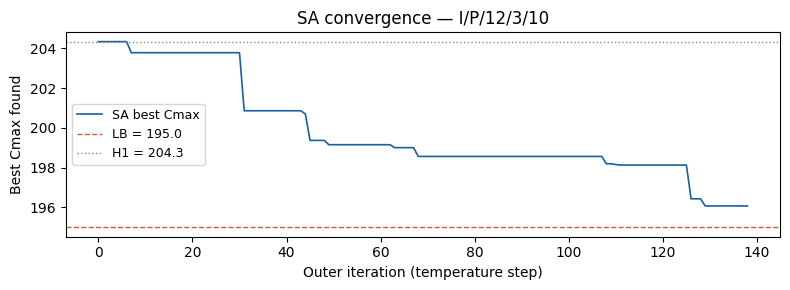


Final gap vs LB: 0.55%


In [27]:
import matplotlib.pyplot as plt

inst = generate_instance(12, 3, 10, family="H", seed=5)
lb   = lower_bound(inst)

#run SA with verbose output (for cooling observation)
sol_sa, history = simulated_annealing(
    inst,
    alpha    = 0.97,
    max_iter = 5000,
    seed     = 42,
    verbose  = True,
)
sol_h1 = h1(inst)

print_instance(inst)
print_solution(inst, sol_h1, label="H1 (initial solution)")
print_solution(inst, sol_sa, label="SA (after search)")

#convergence plot
plt.figure(figsize=(8, 3))
plt.plot(history, linewidth=1.2, color="#185FA5", label="SA best Cmax")
plt.axhline(lb,          color="#D85A30", linestyle="--", linewidth=1, label=f"LB = {lb:.1f}")
plt.axhline(sol_h1.makespan, color="#888780", linestyle=":",  linewidth=1,
            label=f"H1 = {sol_h1.makespan:.1f}")
plt.xlabel("Outer iteration (temperature step)")
plt.ylabel("Best Cmax found")
plt.title("SA convergence — I/P/12/3/10")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"\nFinal gap vs LB: {(sol_sa.makespan/lb-1)*100:.2f}%")

# MILP

since Gurobi is licensed, I am using HiGHS through scipy.optimize.milp. It is an open-source MILP solver

In [28]:
import numpy as np
from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import csc_matrix
from typing import List, Tuple, Dict
import time

def solve_milp(inst: Instance,
               time_limit: float = 60.0,
               verbose: bool = False) -> dict:
    """
    Variable layout (one flat vector x of length N):
      x[0]                    Cmax  (continuous, ≥ 0)
      x[1 + k*S + s]          y[k,s]  binary
                              = 1 if machine k gets (s+1) workers
      x[1 + m*S + (i*m+k)*S + s]   z[i,k,s]  binary
                              = 1 if job i → machine k, machine k has (s+1) workers
    """
    n, m, W = inst.n, inst.m, inst.W
    S = W - m + 1                            #number of worker levels
    #worker levels are s = 0..S-1  where  S = W - m + 1
    worker_levels = list(range(1, S + 1))    #actual counts: 1, 2, ..., S
    #each machine gets at least 1 worker, so max for one machine = W - (m-1)

    pt = inst.precompute_pt()[:, :S]         #p[i, s] = p_i(s+1), shape (n, S)

    #variable index helpers
    def idx_cmax(): return 0
    def idx_y(k, s): return 1 + k*S + s
    def idx_z(i,k,s): return 1 + m*S + (i*m + k)*S + s

    N = 1 + m*S + n*m*S

    #objective: minimise x[0] = Cmax
    c_obj = np.zeros(N)
    c_obj[0] = 1.0

    #variable bounds
    lb_v = np.zeros(N)
    ub_v = np.ones(N)
    lb_v[0] = 0.0
    ub_v[0] = np.inf     #Cmax unbounded above

    #integrality: 0 = continuous, 1 = integer (binary)
    integ = np.ones(N, dtype=int)
    integ[0] = 0         #Cmax is continuous

    #build constraint matrix (sparse)
    rows, cols, vals, b_lo, b_hi = [], [], [], [], []

    def add_row(pairs, lo, hi):
        r = len(b_lo)
        for col, val in pairs:
            rows.append(r); cols.append(col); vals.append(float(val))
        b_lo.append(lo); b_hi.append(hi)

    # Constraints taken from Section 16.1.5

    # Constraint (8): each job assigned exactly once
    #sum_{k,s} z[i,k,s] = 1 ∀i (each job assigned once)
    for i in range(n):
        add_row([(idx_z(i,k,s), 1.0) for k in range(m) for s in range(S)],
                1.0, 1.0)

    # Constraint (9): each machine gets exactly one worker level
    #sum_s y[k,s] = 1 ∀k (one worker level per machine)
    for k in range(m):
        add_row([(idx_y(k,s), 1.0) for s in range(S)], 1.0, 1.0)

    # Constraint (10): link jobs to worker level
    #z[i,k,s] <= y[k,s] ∀i,k,s
    for i in range(n):
        for k in range(m):
            for s in range(S):
                add_row([(idx_z(i,k,s), 1.0), (idx_y(k,s), -1.0)],
                        -np.inf, 0.0)

    # Constraint (11): total workers = W
    #sum_{k,s} (s+1)·y[k,s] = W (all workers allocated)
    add_row([(idx_y(k,s), worker_levels[s]) for k in range(m) for s in range(S)],
            float(W), float(W))

    # Constraint (12): machine load <= Cmax  for each machine k
    #sum_{i,s} p[i,s]·z[i,k,s] <= Cmax ∀k (load bound)
    for k in range(m):
        pairs = [(idx_cmax(), -1.0)]
        for i in range(n):
            for s in range(S):
                pairs.append((idx_z(i,k,s), pt[i, s]))
        add_row(pairs, -np.inf, 0.0)

    A_sp = csc_matrix((vals, (rows, cols)), shape=(len(b_lo), N))
    constraints = LinearConstraint(A_sp, np.array(b_lo), np.array(b_hi))
    bounds = Bounds(lb=lb_v, ub=ub_v)

    #solve
    t0 = time.time()
    res = milp(c_obj,
               constraints=constraints,
               integrality=integ,
               bounds=bounds,
               options={"disp": verbose,
                        "time_limit": time_limit,
                        "mip_rel_gap": 1e-4})
    wall = time.time() - t0

    status_map = {0:"optimal", 1:"timeout", 2:"infeasible",
                  3:"infeasible", 4:"timeout"}
    status = status_map.get(res.status, "unknown")

    if res.fun is None or res.x is None:
        return {"status": status, "makespan": float("inf"),
                "gap_pct": None, "solution": None, "wall_sec": wall}

    x = res.x

    #recover assignment and workers from binary variables
    workers_sol = [1] * m       #default: 1 worker (should be overwritten)
    assignment = [-1] * n

    for k in range(m):
        for s in range(S):
            if x[idx_y(k, s)] > 0.5:
                workers_sol[k] = worker_levels[s]
                break

    for i in range(n):
        for k in range(m):
            for s in range(S):
                if x[idx_z(i, k, s)] > 0.5:
                    assignment[i] = k
                    break
            if assignment[i] != -1:
                break

    #fallback for any unassigned jobs (numerical noise at integrality gap)
    for i in range(n):
        if assignment[i] == -1:
            assignment[i] = 0

    sol = Solution(
        assignment=assignment,
        workers=workers_sol,
        makespan=compute_makespan(inst, assignment, workers_sol)
    )

    lb = lower_bound(inst)
    gap_pct = (sol.makespan / lb - 1) * 100

    return {
        "status": status, # 'optimal' | 'timeout' | 'infeasible'
        "makespan": sol.makespan, #best Cmax found (float)
        "gap_pct": gap_pct,  #% above LB (0.0 if proven optimal)
        "solution": sol, #Solution object (or None)
        "wall_sec": wall, #wall-clock solve time
    }

test run

In [29]:
def test_milp_small():
    print("--- MILP on small instances (n=6, m=3, W=10) ---")
    for seed in range(5):
        inst = generate_instance(6, 3, 10, family="H", seed=seed)
        lb   = lower_bound(inst)
        r    = solve_milp(inst, time_limit=30.0)
        h1_c = h1(inst).makespan
        print(f"  seed={seed}  status={r['status']:<8}  "
              f"MILP={r['makespan']:.2f}  H1={h1_c:.2f}  "
              f"gap={r['gap_pct']:.2f}%  time={r['wall_sec']:.1f}s")
        assert r['status'] in ('optimal','feasible'), f"Unexpected status: {r['status']}"
        assert r['makespan'] <= h1_c + 1e-6, "MILP must be <= H1 (MILP is exact)"


def test_milp_beats_sa():
    print("\n--- MILP vs SA on I/P/12/3/10 seed=5 ---")
    inst = generate_instance(12, 3, 10, family="H", seed=5)
    lb   = lower_bound(inst)

    sa_sol, _ = simulated_annealing(inst, max_iter=5000, seed=42)
    r_milp     = solve_milp(inst, time_limit=60.0)

    print(f"  LB   = {lb:.4f}")
    print(f"  SA   Cmax = {sa_sol.makespan:.4f}   gap = {(sa_sol.makespan/lb-1)*100:.2f}%")
    print(f"  MILP Cmax = {r_milp['makespan']:.4f}   gap = {r_milp['gap_pct']:.2f}%"
          f"   status={r_milp['status']}   time={r_milp['wall_sec']:.1f}s")

    if r_milp['status'] == 'optimal':
        print(f"MILP found proven optimum")
        print(f"SA was {sa_sol.makespan - r_milp['makespan']:.4f} above optimum "
              f"({(sa_sol.makespan/r_milp['makespan']-1)*100:.2f}%)")


def test_milp_feasibility():
    print("\n--- MILP feasibility on 10 instances ---")
    passed = 0
    for seed in range(10):
        inst = generate_instance(6, 3, 10, family="H", seed=seed)
        r = solve_milp(inst, time_limit=20.0)
        if r['solution']:
            ok, msg = is_feasible(inst, r['solution'].assignment, r['solution'].workers)
            assert ok, f"MILP infeasible seed={seed}: {msg}"
            passed += 1
    print(f"{passed}/10 solutions feasible")


test_milp_small()
test_milp_beats_sa()
test_milp_feasibility()
print("\nAll MILP tests passed!")

--- MILP on small instances (n=6, m=3, W=10) ---
  seed=0  status=optimal   MILP=89.14  H1=89.38  gap=3.09%  time=0.7s
  seed=1  status=optimal   MILP=98.51  H1=99.02  gap=3.41%  time=1.4s
  seed=2  status=optimal   MILP=97.50  H1=98.39  gap=7.71%  time=1.8s
  seed=3  status=optimal   MILP=81.18  H1=81.47  gap=7.07%  time=0.8s
  seed=4  status=optimal   MILP=182.11  H1=182.22  gap=10.00%  time=2.0s

--- MILP vs SA on I/P/12/3/10 seed=5 ---
  LB   = 194.9970
  SA   Cmax = 196.0775   gap = 0.55%
  MILP Cmax = 195.9765   gap = 0.50%   status=optimal   time=6.2s
MILP found proven optimum
SA was 0.1011 above optimum (0.05%)

--- MILP feasibility on 10 instances ---
10/10 solutions feasible

All MILP tests passed!


# Small test run: H1, H2, SA, and MILP

In [30]:
#full comparison table: H1, H2, SA, MILP on Family H
#expected MILP timeouts on n=12

results = []
N_INST = 10
print(f"Comparing H1, H2, SA, MILP on {N_INST} instances of I/P/6/3/10...\n")
print(f"  {'seed':>4}  {'LB':>8}  {'H1':>8}  {'H2':>8}  {'SA':>8}  {'MILP':>8}  {'MILP status'}")
print(f"  {'─'*4}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*11}")

for seed in range(N_INST):
    inst = generate_instance(6, 3, 10, family="H", seed=seed)
    lb   = lower_bound(inst)
    c_h1 = h1(inst).makespan
    c_h2 = h2(inst).makespan
    c_sa, _ = simulated_annealing(inst, max_iter=3000, seed=seed)
    c_sa = c_sa.makespan
    r_m  = solve_milp(inst, time_limit=30.0)
    c_m  = r_m['makespan']

    results.append({"lb":lb,"h1":c_h1,"h2":c_h2,"sa":c_sa,"milp":c_m,
                    "milp_status":r_m["status"]})
    print(f"  {seed:>4}  {lb:>8.2f}  {c_h1:>8.2f}  {c_h2:>8.2f}  "
          f"{c_sa:>8.2f}  {c_m:>8.2f}  {r_m['status']}")

#summary
import numpy as np
lbs  = [r["lb"]   for r in results]
h1s  = [r["h1"]   for r in results]
h2s  = [r["h2"]   for r in results]
sas  = [r["sa"]   for r in results]
ms   = [r["milp"] for r in results]

def avg_gap(cmaxes, lbs):
    return np.mean([(c/lb-1)*100 for c,lb in zip(cmaxes,lbs)])

print(f"\n  {'─'*60}")
print(f"  Average gap vs LB:")
print(f"    H1  : {avg_gap(h1s,lbs):.2f}%")
print(f"    H2  : {avg_gap(h2s,lbs):.2f}%")
print(f"    SA  : {avg_gap(sas,lbs):.2f}%")
print(f"    MILP: {avg_gap(ms,lbs):.2f}%")


Comparing H1, H2, SA, MILP on 10 instances of I/P/6/3/10...

  seed        LB        H1        H2        SA      MILP  MILP status
  ────  ────────  ────────  ────────  ────────  ────────  ───────────
     0     86.47     89.38    115.24     89.16     89.14  optimal
     1     95.26     99.02    142.61     98.51     98.51  optimal
     2     90.51     98.39    112.10     97.50     97.50  optimal
     3     75.82     81.47     99.38     81.18     81.18  optimal
     4    165.56    182.22    185.24    182.11    182.11  optimal
     5    110.20    133.77    147.46    129.59    129.59  optimal
     6    104.23    124.49    138.30    114.68    114.68  optimal
     7    149.92    157.16    171.50    153.98    153.98  optimal
     8     91.06     98.78    130.69     98.29     98.29  optimal
     9    110.64    124.56    116.28    116.28    116.28  optimal

  ────────────────────────────────────────────────────────────
  Average gap vs LB:
    H1  : 10.03%
    H2  : 27.93%
    SA  : 7.47%
    

# Comparisons with Higher Seed Count & Benchmark



We'll be running 500 seeds x 2 configs = 1000 instances

In [31]:
import numpy as np
import time, math
from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import csc_matrix
from openpyxl import Workbook
from openpyxl.styles import (PatternFill, Font, Alignment, Border, Side,
                              GradientFill)
from openpyxl.utils import get_column_letter
from openpyxl.formatting.rule import ColorScaleRule, DataBarRule
import warnings
warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [32]:
def run_benchmark(configs, #list of (n, m, W) tuples
                  n_seeds=500, #number of seeds (0 .. n_seeds-1)
                  sa_max_iter=5000, #SA evaluation budget per instance
                  verbose=True): #print one progress line per config × 50 seeds

    all_rows = []
    total = len(configs) * n_seeds
    done = 0
    t_global = time.time()

    for (n, m, W) in configs:
        cfg = f"I/P/{n}/{m}/{W}"
        if verbose:
            print(f"{'─'*55}")
            print(f"Config {cfg}  ({n_seeds} seeds, no time limit on MILP)")
            print(f"{'─'*55}")

        for seed in range(n_seeds):
            inst = generate_instance(n, m, W, family="H", seed=seed)
            lb = lower_bound(inst)

            #H1
            t0 = time.time()
            s_h1 = h1(inst)
            t_h1 = time.time() - t0

            #H2
            t0 = time.time()
            s_h2 = h2(inst)
            t_h2 = time.time() - t0

            #SA
            t0 = time.time()
            s_sa, _ = simulated_annealing(inst, max_iter=SA_EVALS, seed=seed)
            t_sa = time.time() - t0

            #MILP
            t0 = time.time()
            mr = solve_milp(inst)          # no time_limit argument
            t_m = time.time() - t0

            #gap helpers
            def gap_lb(c):
                return round((c / lb - 1) * 100, 4) if lb > 0 else None
            def gap_milp(c):
                if mr["makespan"] in (None, float("inf")): return None
                return round((c / mr["makespan"] - 1) * 100, 4)

            row = {
                #instance info
                "config": cfg,
                "n": n, "m": m, "W": W,
                "seed": seed,
                "LB": round(lb, 4),

                #makespan
                "H1_Cmax": round(s_h1.makespan, 4),
                "H2_Cmax": round(s_h2.makespan, 4),
                "SA_Cmax": round(s_sa.makespan, 4),
                "MILP_Cmax": round(mr["makespan"], 4) if mr["makespan"] != float("inf") else None,

                #gap vs LB (%)
                "H1_gap_LB": gap_lb(s_h1.makespan),
                "H2_gap_LB": gap_lb(s_h2.makespan),
                "SA_gap_LB": gap_lb(s_sa.makespan),
                "MILP_gap_LB": round(mr["gap_pct"], 4) if mr["gap_pct"] is not None else None,

                #gap vs MILP optimum (%)
                "H1_gap_MILP": gap_milp(s_h1.makespan),
                "H2_gap_MILP": gap_milp(s_h2.makespan),
                "SA_gap_MILP": gap_milp(s_sa.makespan),

                #worker allocation
                "H1_workers": str(s_h1.workers),
                "H2_workers": str(s_h2.workers),
                "SA_workers": str(s_sa.workers),
                "MILP_workers": str(mr["solution"].workers) if mr["solution"] else None,

                #runtime
                "H1_sec": round(t_h1, 4),
                "H2_sec": round(t_h2, 4),
                "SA_sec": round(t_sa, 4),
                "MILP_sec": round(t_m,  4),

                #MILP proof status
                "MILP_status": mr["status"],
            }
            all_rows.append(row)
            done += 1

            #progress report every 50 seeds
            if verbose and (seed + 1) % 50 == 0:
                elapsed = time.time() - t_global
                rate    = done / elapsed
                eta_min = (total - done) / rate / 60
                print(f"seed {seed+1:>4}/{n_seeds}  |  "
                      f"elapsed {elapsed/60:.1f} min  |  "
                      f"ETA {eta_min:.1f} min  |  "
                      f"last MILP {t_m:.1f}s ({mr['status']})")

    print(f"Done. {done} instances solved in "
          f"{(time.time()-t_global)/60:.1f} min.")
    return all_rows

for h3, h4, GA

In [33]:
def run_benchmark(configs, #list of (n, m, W) tuples
                  n_seeds=500, #number of seeds (0 .. n_seeds-1)
                  sa_max_iter=5000, #SA evaluation budget per instance
                  verbose=True): #print one progress line per config × 50 seeds

    all_rows = []
    total = len(configs) * n_seeds
    done = 0
    t_global = time.time()

    for (n, m, W) in configs:
        cfg = f"I/P/{n}/{m}/{W}"
        if verbose:
            print(f"{'─'*55}")
            print(f"Config {cfg}  ({n_seeds} seeds, no time limit on MILP)")
            print(f"{'─'*55}")

        for seed in range(n_seeds):
            inst = generate_instance(n, m, W, family="H", seed=seed)
            lb = lower_bound(inst)

            #H3
            t0 = time.time()
            s_h3 = h3(inst)
            t_h3 = time.time() - t0

            #H4
            t0 = time.time()
            s_h4 = h2(inst)
            t_h4 = time.time() - t0

            #GA
            t0 = time.time()
            # s_ga, _ = simulated_annealing(inst, max_iter=SA_EVALS, seed=seed)
            # t_ga = time.time() - t0

            s_ga, _ = genetic_algorithm(inst, pop_size=50, n_gen=200, stall_limit=50, seed=seed)
            t_ga = time.time() - t0
            # #MILP
            # t0 = time.time()
            # mr = solve_milp(inst)          # no time_limit argument
            # t_m = time.time() - t0

            #gap helpers
            def gap_lb(c):
                return round((c / lb - 1) * 100, 4) if lb > 0 else None
            # def gap_milp(c):
            #     if mr["makespan"] in (None, float("inf")): return None
            #     return round((c / mr["makespan"] - 1) * 100, 4)

            row = {
                #instance info
                "config": cfg,
                "n": n, "m": m, "W": W,
                "seed": seed,
                "LB": round(lb, 4),

                #makespan
                "H3_Cmax": round(s_h3.makespan, 4),
                "H4_Cmax": round(s_h4.makespan, 4),
                "GA_Cmax": round(s_ga.makespan, 4),

                #gap vs LB (%)
                "H3_gap_LB": gap_lb(s_h3.makespan),
                "H4_gap_LB": gap_lb(s_h4.makespan),
                "GA_gap_LB": gap_lb(s_ga.makespan),

                # #gap vs MILP optimum (%)
                # "H1_gap_MILP": gap_milp(s_h1.makespan),
                # "H2_gap_MILP": gap_milp(s_h2.makespan),
                # "SA_gap_MILP": gap_milp(s_sa.makespan),

                #worker allocation
                "H3_workers": str(s_h3.workers),
                "H4_workers": str(s_h4.workers),
                "GA_workers": str(s_ga.workers),

                #runtime
                "H3_sec": round(t_h3, 4),
                "H4_sec": round(t_h4, 4),
                "GA_sec": round(t_ga, 4),


            }
            all_rows.append(row)
            done += 1

            #progress report every 50 seeds
            if verbose and (seed + 1) % 50 == 0:
                elapsed = time.time() - t_global
                rate    = done / elapsed
                eta_min = (total - done) / rate / 60
                print(f"seed {seed+1:>4}/{n_seeds}  |  "
                      f"elapsed {elapsed/60:.1f} min  |  "
                      f"ETA {eta_min:.1f} min  |  ")

    print(f"Done. {done} instances solved in "
          f"{(time.time()-t_global)/60:.1f} min.")
    return all_rows

Excel Generator


In [34]:
def export_excel(rows: list, filepath: str = "benchmark_results.xlsx"):
    import numpy as np
    wb = Workbook()

    #colors for visual affect
    HDR_FILL  = PatternFill("solid", fgColor="1F3864")   # dark navy
    ALG_FILLS = {
        "H1": PatternFill("solid", fgColor="D6E4F0"),  # light blue
        "H2": PatternFill("solid", fgColor="FCE4D6"),  # light orange
        "SA": PatternFill("solid", fgColor="E2EFDA"),  # light green
        "MILP": PatternFill("solid", fgColor="EDE7F6"),  # light purple
    }
    HDR_FONT   = Font(bold=True, color="FFFFFF", size=11)
    TITLE_FONT = Font(bold=True, size=12)
    BORDER     = Border(
        left=Side(style="thin"), right=Side(style="thin"),
        top=Side(style="thin"),  bottom=Side(style="thin")
    )
    CENTER = Alignment(horizontal="center", vertical="center")

    def style_header(cell, alg=None):
        cell.font      = HDR_FONT if alg is None else Font(bold=True, size=10)
        cell.fill      = HDR_FILL if alg is None else ALG_FILLS.get(alg, HDR_FILL)
        cell.alignment = CENTER
        cell.border    = BORDER

    def style_cell(cell, number_format=None):
        cell.border    = BORDER
        cell.alignment = CENTER
        if number_format:
            cell.number_format = number_format

    def set_col_widths(ws, widths):
        for col, w in enumerate(widths, 1):
            ws.column_dimensions[get_column_letter(col)].width = w

    configs = sorted(set((r["config"], r["n"], r["m"], r["W"]) for r in rows),
                     key=lambda x: (x[1], x[0]))
    algs    = ["H1", "H2", "SA", "MILP"]

    #sheet 1 : raw data; every result row, colour-scaled gap column
    ws1 = wb.active
    ws1.title = "Raw Data"
    ws1.freeze_panes = "A2"

    headers = [
        "Config","n","m","W","Seed","LB",
        "H1 Cmax","H2 Cmax","SA Cmax","MILP Cmax",
        "H1 Gap%","H2 Gap%","SA Gap%","MILP Gap%",
        "H1 vs MILP%","H2 vs MILP%","SA vs MILP%",
        "H1 Workers","H2 Workers","SA Workers","MILP Workers",
        "H1 sec","H2 sec","SA sec","MILP sec","MILP Status"
    ]
    col_keys = [
        "config","n","m","W","seed","LB",
        "H1_Cmax","H2_Cmax","SA_Cmax","MILP_Cmax",
        "H1_gap_LB","H2_gap_LB","SA_gap_LB","MILP_gap_LB",
        "H1_gap_MILP","H2_gap_MILP","SA_gap_MILP",
        "H1_workers","H2_workers","SA_workers","MILP_workers",
        "H1_sec","H2_sec","SA_sec","MILP_sec","MILP_status"
    ]
    for ci, h in enumerate(headers, 1):
        cell = ws1.cell(row=1, column=ci, value=h)
        style_header(cell)

    for ri, row in enumerate(rows, 2):
        for ci, key in enumerate(col_keys, 1):
            val  = row.get(key)
            cell = ws1.cell(row=ri, column=ci, value=val)
            style_cell(cell)
            #number formats
            if key == "LB" or key.endswith("_Cmax"):
                cell.number_format = "0.0000"
            elif key.endswith("_gap_LB") or key.endswith("_gap_MILP") or key.endswith("_gap_pct"):
                cell.number_format = "0.00%"
            elif key.endswith("_sec"):
                cell.number_format = "0.000"

    #conditional formatting: colour-scale on SA gap column
    sa_gap_col = get_column_letter(headers.index("SA Gap%") + 1)
    last_row   = len(rows) + 1
    ws1.conditional_formatting.add(
        f"{sa_gap_col}2:{sa_gap_col}{last_row}",
        ColorScaleRule(start_type="min", start_color="63BE7B",
                       mid_type="percentile", mid_value=50, mid_color="FFEB84",
                       end_type="max", end_color="F8696B")
    )

    set_col_widths(ws1, [14,4,4,4,6,10,
                         10,10,10,10,
                         9,9,9,9,
                         12,12,12,
                         14,14,14,14,
                         8,8,8,8,10])

    #sheet 2 : summary of statistics; avg/min/max/std Cmax and gap per algorithm per config
    ws2 = wb.create_sheet("Stats")
    ws2.freeze_panes = "A3"

    stat_headers = ["Config","Algorithm",
                    "Avg Cmax","Min Cmax","Max Cmax","Std Cmax",
                    "Avg Gap% vs LB","Min Gap%","Max Gap%","Std Gap%",
                    "Avg Gap% vs MILP","Instances"]
    for ci, h in enumerate(stat_headers, 1):
        cell = ws2.cell(row=1, column=ci, value=h)
        style_header(cell)

    row_num = 2
    for (cfg, n, m, W) in configs:
        cfg_rows = [r for r in rows if r["config"] == cfg]
        for alg in algs:
            cmaxes = [r[f"{alg}_Cmax"] for r in cfg_rows if r[f"{alg}_Cmax"] is not None]
            gaps_lb = [r[f"{alg}_gap_LB"] for r in cfg_rows if r.get(f"{alg}_gap_LB") is not None]
            gaps_m  = [r.get(f"{alg}_gap_MILP") for r in cfg_rows
                       if r.get(f"{alg}_gap_MILP") is not None] if alg != "MILP" else []

            vals = [
                cfg, alg,
                round(np.mean(cmaxes), 4)  if cmaxes  else None,
                round(np.min(cmaxes),  4)  if cmaxes  else None,
                round(np.max(cmaxes),  4)  if cmaxes  else None,
                round(np.std(cmaxes),  4)  if cmaxes  else None,
                round(np.mean(gaps_lb),4)  if gaps_lb else None,
                round(np.min(gaps_lb), 4)  if gaps_lb else None,
                round(np.max(gaps_lb), 4)  if gaps_lb else None,
                round(np.std(gaps_lb), 4)  if gaps_lb else None,
                round(np.mean(gaps_m), 4)  if gaps_m  else "—",
                len(cmaxes),
            ]
            for ci, val in enumerate(vals, 1):
                cell = ws2.cell(row=row_num, column=ci, value=val)
                style_cell(cell)
                cell.fill = ALG_FILLS.get(alg, PatternFill())
                if ci in (3,4,5,6): cell.number_format = "0.0000"
                if ci in (7,8,9,10,11): cell.number_format = "0.00"
            row_num += 1
        #blank separator row between configs
        row_num += 1

    set_col_widths(ws2, [14,8,10,10,10,10,14,10,10,10,16,10])

    #sheet 3 : head-to-head comparisons; win/tie/loss between every algorithm pair
    ws3 = wb.create_sheet("Head-to-Head")

    pairs = [("H1","H2"),("H1","SA"),("H1","MILP"),
             ("H2","SA"),("H2","MILP"),("SA","MILP")]

    h2h_headers = ["Config","A vs B","A wins","B wins","Ties","Total","A win%","B win%"]
    for ci, h in enumerate(h2h_headers, 1):
        cell = ws3.cell(row=1, column=ci, value=h)
        style_header(cell)

    row_num = 2
    for (cfg, n, m, W) in configs:
        cfg_rows = [r for r in rows if r["config"] == cfg]
        for (a, b) in pairs:
            a_wins = b_wins = ties = 0
            for r in cfg_rows:
                ca = r.get(f"{a}_Cmax"); cb = r.get(f"{b}_Cmax")
                if ca is None or cb is None: continue
                if ca < cb - 1e-6:   a_wins += 1
                elif cb < ca - 1e-6: b_wins += 1
                else:                ties   += 1
            total = a_wins + b_wins + ties
            vals = [cfg, f"{a} vs {b}", a_wins, b_wins, ties, total,
                    round(a_wins/total*100,1) if total else 0,
                    round(b_wins/total*100,1) if total else 0]
            for ci, val in enumerate(vals, 1):
                cell = ws3.cell(row=row_num, column=ci, value=val)
                style_cell(cell)
            row_num += 1
        row_num += 1

    set_col_widths(ws3, [14,14,8,8,8,8,8,8])

    #sheet 4 : worker allocation; avg workers per machine, most common allocation
    ws4 = wb.create_sheet("Worker Allocation")

    # Parse worker strings "[a, b, c]" → list of ints
    def parse_workers(s):
        if s is None: return None
        try: return list(map(int, s.strip("[]").split(",")))
        except: return None

    wa_headers = ["Config","Algorithm","Avg M0 workers","Avg M1 workers","Avg M2 workers",
                  "Std M0","Std M1","Std M2","Most common allocation"]
    for ci, h in enumerate(wa_headers, 1):
        cell = ws4.cell(row=1, column=ci, value=h)
        style_header(cell)

    row_num = 2
    for (cfg, n, m, W) in configs:
        cfg_rows = [r for r in rows if r["config"] == cfg]
        for alg in algs:
            wlist = [parse_workers(r[f"{alg}_workers"]) for r in cfg_rows]
            wlist = [w for w in wlist if w is not None and len(w) == m]
            if not wlist:
                row_num += 1; continue
            arr = np.array(wlist)   #shape (n_inst, m)
            avgs = arr.mean(axis=0)
            stds = arr.std(axis=0)
            #most common allocation
            from collections import Counter
            most_common = Counter(map(tuple, wlist)).most_common(1)[0][0]
            vals = ([cfg, alg] +
                    [round(avgs[k],2) for k in range(m)] +
                    [round(stds[k],2) for k in range(m)] +
                    [str(list(most_common))])
            for ci, val in enumerate(vals, 1):
                cell = ws4.cell(row=row_num, column=ci, value=val)
                style_cell(cell)
                cell.fill = ALG_FILLS.get(alg, PatternFill())
            row_num += 1
        row_num += 1

    set_col_widths(ws4, [14,8,14,14,14,10,10,10,22])

    #sheet 5 : runtime; avg/min/max/total seconds per algorithm
    ws5 = wb.create_sheet("Runtime")

    rt_headers = ["Config","Algorithm","Avg sec","Min sec","Max sec","Std sec","Total sec"]
    for ci, h in enumerate(rt_headers, 1):
        cell = ws5.cell(row=1, column=ci, value=h)
        style_header(cell)

    row_num = 2
    for (cfg, n, m, W) in configs:
        cfg_rows = [r for r in rows if r["config"] == cfg]
        for alg in algs:
            times = [r[f"{alg}_sec"] for r in cfg_rows if r.get(f"{alg}_sec") is not None]
            if not times: row_num += 1; continue
            vals = [cfg, alg,
                    round(np.mean(times),4), round(np.min(times),4),
                    round(np.max(times),4),  round(np.std(times),4),
                    round(np.sum(times),2)]
            for ci, val in enumerate(vals, 1):
                cell = ws5.cell(row=row_num, column=ci, value=val)
                style_cell(cell)
                cell.fill = ALG_FILLS.get(alg, PatternFill())
                if ci >= 3: cell.number_format = "0.0000"
            row_num += 1
        row_num += 1

    set_col_widths(ws5, [14,8,10,10,10,10,10])

    wb.save(filepath)
    print(f"\nExcel saved to -> {filepath}")
    print(f"Sheets: {[ws.title for ws in wb.worksheets]}")
    print(f"Raw Data rows: {len(rows)}")

For h3, h4, GA

In [35]:
def export_excel(rows: list, filepath: str = "benchmark_results.xlsx"):
    import numpy as np
    wb = Workbook()

    #colors for visual affect
    HDR_FILL  = PatternFill("solid", fgColor="1F3864")   # dark navy
    ALG_FILLS = {
        "H3": PatternFill("solid", fgColor="D6E4F0"),  # light blue
        "H4": PatternFill("solid", fgColor="FCE4D6"),  # light orange
        "GA": PatternFill("solid", fgColor="E2EFDA"),  # light green
    }
    HDR_FONT   = Font(bold=True, color="FFFFFF", size=11)
    TITLE_FONT = Font(bold=True, size=12)
    BORDER     = Border(
        left=Side(style="thin"), right=Side(style="thin"),
        top=Side(style="thin"),  bottom=Side(style="thin")
    )
    CENTER = Alignment(horizontal="center", vertical="center")

    def style_header(cell, alg=None):
        cell.font      = HDR_FONT if alg is None else Font(bold=True, size=10)
        cell.fill      = HDR_FILL if alg is None else ALG_FILLS.get(alg, HDR_FILL)
        cell.alignment = CENTER
        cell.border    = BORDER

    def style_cell(cell, number_format=None):
        cell.border    = BORDER
        cell.alignment = CENTER
        if number_format:
            cell.number_format = number_format

    def set_col_widths(ws, widths):
        for col, w in enumerate(widths, 1):
            ws.column_dimensions[get_column_letter(col)].width = w

    configs = sorted(set((r["config"], r["n"], r["m"], r["W"]) for r in rows),
                     key=lambda x: (x[1], x[0]))
    algs    = ["H3", "H4", "GA"]

    #sheet 1 : raw data; every result row, colour-scaled gap column
    ws1 = wb.active
    ws1.title = "Raw Data"
    ws1.freeze_panes = "A2"

    headers = [
        "Config","n","m","W","Seed","LB",
        "H3 Cmax","H4 Cmax","GA Cmax",
        "H3 Gap%","H4 Gap%","GA Gap%",
        "H3 Workers","H4 Workers","GA Workers",
        "H3 sec","H4 sec","GA sec"
    ]
    col_keys = [
        "config","n","m","W","seed","LB",
        "H3_Cmax","H4_Cmax","GA_Cmax",
        "H3_gap_LB","H4_gap_LB","GA_gap_LB",
        "H3_workers","H4_workers","GA_workers",
        "H3_sec","H4_sec","GA_sec"
    ]
    for ci, h in enumerate(headers, 1):
        cell = ws1.cell(row=1, column=ci, value=h)
        style_header(cell)

    for ri, row in enumerate(rows, 2):
        for ci, key in enumerate(col_keys, 1):
            val  = row.get(key)
            cell = ws1.cell(row=ri, column=ci, value=val)
            style_cell(cell)
            #number formats
            if key == "LB" or key.endswith("_Cmax"):
                cell.number_format = "0.0000"
            elif key.endswith("_gap_LB") or key.endswith("_gap_MILP") or key.endswith("_gap_pct"):
                cell.number_format = "0.00%"
            elif key.endswith("_sec"):
                cell.number_format = "0.000"

    #conditional formatting: colour-scale on SA gap column
    ga_gap_col = get_column_letter(headers.index("GA Gap%") + 1)
    last_row   = len(rows) + 1
    ws1.conditional_formatting.add(
        f"{ga_gap_col}2:{ga_gap_col}{last_row}",
        ColorScaleRule(start_type="min", start_color="63BE7B",
                       mid_type="percentile", mid_value=50, mid_color="FFEB84",
                       end_type="max", end_color="F8696B")
    )

    set_col_widths(ws1, [14,4,4,4,6,10,
                         10,10,10,10,
                         9,9,9,9,
                         12,12,12,
                         14,14,14,14,
                         8,8,8,8,10])

    #sheet 2 : summary of statistics; avg/min/max/std Cmax and gap per algorithm per config
    ws2 = wb.create_sheet("Stats")
    ws2.freeze_panes = "A3"

    stat_headers = ["Config","Algorithm",
                    "Avg Cmax","Min Cmax","Max Cmax","Std Cmax",
                    "Avg Gap% vs LB","Min Gap%","Max Gap%","Std Gap%","Instances"]
    for ci, h in enumerate(stat_headers, 1):
        cell = ws2.cell(row=1, column=ci, value=h)
        style_header(cell)

    row_num = 2
    for (cfg, n, m, W) in configs:
        cfg_rows = [r for r in rows if r["config"] == cfg]
        for alg in algs:
            cmaxes = [r[f"{alg}_Cmax"] for r in cfg_rows if r[f"{alg}_Cmax"] is not None]
            gaps_lb = [r[f"{alg}_gap_LB"] for r in cfg_rows if r.get(f"{alg}_gap_LB") is not None]
            # gaps_m  = [r.get(f"{alg}_gap_MILP") for r in cfg_rows
            #            if r.get(f"{alg}_gap_MILP") is not None] if alg != "MILP" else []

            vals = [
                cfg, alg,
                round(np.mean(cmaxes), 4)  if cmaxes  else None,
                round(np.min(cmaxes),  4)  if cmaxes  else None,
                round(np.max(cmaxes),  4)  if cmaxes  else None,
                round(np.std(cmaxes),  4)  if cmaxes  else None,
                round(np.mean(gaps_lb),4)  if gaps_lb else None,
                round(np.min(gaps_lb), 4)  if gaps_lb else None,
                round(np.max(gaps_lb), 4)  if gaps_lb else None,
                round(np.std(gaps_lb), 4)  if gaps_lb else None,
                # round(np.mean(gaps_m), 4)  if gaps_m  else "—",
                len(cmaxes),
            ]
            for ci, val in enumerate(vals, 1):
                cell = ws2.cell(row=row_num, column=ci, value=val)
                style_cell(cell)
                cell.fill = ALG_FILLS.get(alg, PatternFill())
                if ci in (3,4,5,6): cell.number_format = "0.0000"
                if ci in (7,8,9,10,11): cell.number_format = "0.00"
            row_num += 1
        #blank separator row between configs
        row_num += 1

    set_col_widths(ws2, [14,8,10,10,10,10,14,10,10,10,16,10])

    #sheet 3 : head-to-head comparisons; win/tie/loss between every algorithm pair
    ws3 = wb.create_sheet("Head-to-Head")

    pairs = [("H3","H4"),("H3","GA"),
             ("H4","GA")]

    h2h_headers = ["Config","A vs B","A wins","B wins","Ties","Total","A win%","B win%"]
    for ci, h in enumerate(h2h_headers, 1):
        cell = ws3.cell(row=1, column=ci, value=h)
        style_header(cell)

    row_num = 2
    for (cfg, n, m, W) in configs:
        cfg_rows = [r for r in rows if r["config"] == cfg]
        for (a, b) in pairs:
            a_wins = b_wins = ties = 0
            for r in cfg_rows:
                ca = r.get(f"{a}_Cmax"); cb = r.get(f"{b}_Cmax")
                if ca is None or cb is None: continue
                if ca < cb - 1e-6:   a_wins += 1
                elif cb < ca - 1e-6: b_wins += 1
                else:                ties   += 1
            total = a_wins + b_wins + ties
            vals = [cfg, f"{a} vs {b}", a_wins, b_wins, ties, total,
                    round(a_wins/total*100,1) if total else 0,
                    round(b_wins/total*100,1) if total else 0]
            for ci, val in enumerate(vals, 1):
                cell = ws3.cell(row=row_num, column=ci, value=val)
                style_cell(cell)
            row_num += 1
        row_num += 1

    set_col_widths(ws3, [14,14,8,8,8,8,8,8])

    #sheet 4 : worker allocation; avg workers per machine, most common allocation
    ws4 = wb.create_sheet("Worker Allocation")

    # Parse worker strings "[a, b, c]" → list of ints
    def parse_workers(s):
        if s is None: return None
        try: return list(map(int, s.strip("[]").split(",")))
        except: return None

    wa_headers = ["Config","Algorithm","Avg M0 workers","Avg M1 workers","Avg M2 workers",
                  "Std M0","Std M1","Std M2","Most common allocation"]
    for ci, h in enumerate(wa_headers, 1):
        cell = ws4.cell(row=1, column=ci, value=h)
        style_header(cell)

    row_num = 2
    for (cfg, n, m, W) in configs:
        cfg_rows = [r for r in rows if r["config"] == cfg]
        for alg in algs:
            wlist = [parse_workers(r[f"{alg}_workers"]) for r in cfg_rows]
            wlist = [w for w in wlist if w is not None and len(w) == m]
            if not wlist:
                row_num += 1; continue
            arr = np.array(wlist)   #shape (n_inst, m)
            avgs = arr.mean(axis=0)
            stds = arr.std(axis=0)
            #most common allocation
            from collections import Counter
            most_common = Counter(map(tuple, wlist)).most_common(1)[0][0]
            vals = ([cfg, alg] +
                    [round(avgs[k],2) for k in range(m)] +
                    [round(stds[k],2) for k in range(m)] +
                    [str(list(most_common))])
            for ci, val in enumerate(vals, 1):
                cell = ws4.cell(row=row_num, column=ci, value=val)
                style_cell(cell)
                cell.fill = ALG_FILLS.get(alg, PatternFill())
            row_num += 1
        row_num += 1

    set_col_widths(ws4, [14,8,14,14,14,10,10,10,22])

    #sheet 5 : runtime; avg/min/max/total seconds per algorithm
    ws5 = wb.create_sheet("Runtime")

    rt_headers = ["Config","Algorithm","Avg sec","Min sec","Max sec","Std sec","Total sec"]
    for ci, h in enumerate(rt_headers, 1):
        cell = ws5.cell(row=1, column=ci, value=h)
        style_header(cell)

    row_num = 2
    for (cfg, n, m, W) in configs:
        cfg_rows = [r for r in rows if r["config"] == cfg]
        for alg in algs:
            times = [r[f"{alg}_sec"] for r in cfg_rows if r.get(f"{alg}_sec") is not None]
            if not times: row_num += 1; continue
            vals = [cfg, alg,
                    round(np.mean(times),4), round(np.min(times),4),
                    round(np.max(times),4),  round(np.std(times),4),
                    round(np.sum(times),2)]
            for ci, val in enumerate(vals, 1):
                cell = ws5.cell(row=row_num, column=ci, value=val)
                style_cell(cell)
                cell.fill = ALG_FILLS.get(alg, PatternFill())
                if ci >= 3: cell.number_format = "0.0000"
            row_num += 1
        row_num += 1

    set_col_widths(ws5, [14,8,10,10,10,10,10])

    wb.save(filepath)
    print(f"\nExcel saved to -> {filepath}")
    print(f"Sheets: {[ws.title for ws in wb.worksheets]}")
    print(f"Raw Data rows: {len(rows)}")

run tests

In [36]:
import json, os

CHECKPOINT = "benchmark_checkpoint.json"

def save_checkpoint(rows, filepath=CHECKPOINT):
    with open(filepath, "w") as f:
        json.dump(rows, f)
    print(f"Checkpoint saved: {len(rows)} rows → {filepath}")

def load_checkpoint(filepath=CHECKPOINT):
    if not os.path.exists(filepath):
        print("No checkpoint found.")
        return []
    with open(filepath) as f:
        rows = json.load(f)
    print(f"Loaded checkpoint: {len(rows)} rows from {filepath}")
    return rows

#running while checkpointing in case it takes time
CONFIGS  = [(6, 3, 10), (12, 3, 10)]
N_SEEDS  = 500
SA_EVALS = 5000

#resume from checkpoint if it exists
results = load_checkpoint()
done_keys = set((r["config"], r["seed"]) for r in results)
print(f"Already done: {len(done_keys)} instances")

import time, math
t_global = time.time()

for (n, m, W) in CONFIGS:
    cfg = f"I/P/{n}/{m}/{W}"
    print(f"\n{'-'*55}\nConfig{cfg}\n{'-'*55}")
    for seed in range(N_SEEDS):
        if (cfg, seed) in done_keys:
            continue  #skip already-computed

        inst = generate_instance(n, m, W, family="H", seed=seed)
        lb   = lower_bound(inst)

        t0=time.time(); s_h1=h1(inst);  t_h1=time.time()-t0
        t0=time.time(); s_h2=h2(inst);  t_h2=time.time()-t0
        t0=time.time(); s_sa, _ = simulated_annealing(inst, max_iter=SA_EVALS, seed=seed); t_sa=time.time()-t0
        t0=time.time(); mr=solve_milp(inst); t_m=time.time()-t0

        def gap_lb(c): return round((c/lb-1)*100,4) if lb>0 else None
        def gap_milp(c):
            if mr["makespan"] in (None,float("inf")): return None
            return round((c/mr["makespan"]-1)*100,4)

        row = {
            "config":cfg,"n":n,"m":m,"W":W,"seed":seed,"LB":round(lb,4),
            "H1_Cmax":round(s_h1.makespan,4),"H2_Cmax":round(s_h2.makespan,4),
            "SA_Cmax":round(s_sa.makespan,4),
            "MILP_Cmax":round(mr["makespan"],4) if mr["makespan"]!=float("inf") else None,
            "H1_gap_LB":gap_lb(s_h1.makespan),"H2_gap_LB":gap_lb(s_h2.makespan),
            "SA_gap_LB":gap_lb(s_sa.makespan),
            "MILP_gap_LB":round(mr["gap_pct"],4) if mr["gap_pct"] is not None else None,
            "H1_gap_MILP":gap_milp(s_h1.makespan),"H2_gap_MILP":gap_milp(s_h2.makespan),
            "SA_gap_MILP":gap_milp(s_sa.makespan),
            "H1_workers":str(s_h1.workers),"H2_workers":str(s_h2.workers),
            "SA_workers":str(s_sa.workers),
            "MILP_workers":str(mr["solution"].workers) if mr["solution"] else None,
            "H1_sec":round(t_h1,4),"H2_sec":round(t_h2,4),
            "SA_sec":round(t_sa,4),"MILP_sec":round(t_m,4),
            "MILP_status":mr["status"],
        }
        results.append(row)
        done_keys.add((cfg, seed))

        #save checkpoint every 50 seeds
        if (seed + 1) % 50 == 0:
            save_checkpoint(results)
            elapsed = time.time()-t_global
            total = N_SEEDS*len(CONFIGS)
            done = len(done_keys)
            eta = (total-done)/(done/elapsed)/60 if done>0 else 0
            print(f"seed {seed+1:>4}/{N_SEEDS} | elapsed {elapsed/60:.1f}m | ETA {eta:.1f}m | last MILP {t_m:.1f}s")

save_checkpoint(results)
print(f"\nAll done. {len(results)} instances.")

No checkpoint found.
Already done: 0 instances

-------------------------------------------------------
ConfigI/P/6/3/10
-------------------------------------------------------
Checkpoint saved: 50 rows → benchmark_checkpoint.json
seed   50/500 | elapsed 1.6m | ETA 30.9m | last MILP 4.0s
Checkpoint saved: 100 rows → benchmark_checkpoint.json
seed  100/500 | elapsed 3.4m | ETA 30.2m | last MILP 1.3s
Checkpoint saved: 150 rows → benchmark_checkpoint.json
seed  150/500 | elapsed 5.6m | ETA 31.9m | last MILP 1.1s
Checkpoint saved: 200 rows → benchmark_checkpoint.json
seed  200/500 | elapsed 7.2m | ETA 28.7m | last MILP 1.6s
Checkpoint saved: 250 rows → benchmark_checkpoint.json
seed  250/500 | elapsed 8.6m | ETA 25.8m | last MILP 2.0s
Checkpoint saved: 300 rows → benchmark_checkpoint.json
seed  300/500 | elapsed 10.3m | ETA 23.9m | last MILP 4.3s
Checkpoint saved: 350 rows → benchmark_checkpoint.json
seed  350/500 | elapsed 12.8m | ETA 23.7m | last MILP 6.5s
Checkpoint saved: 400 rows → be

for h3, h4, GA

In [37]:
import json, os

CHECKPOINT = "benchmark_checkpoint.json"

def save_checkpoint(rows, filepath=CHECKPOINT):
    with open(filepath, "w") as f:
        json.dump(rows, f)
    print(f"Checkpoint saved: {len(rows)} rows → {filepath}")

def load_checkpoint(filepath=CHECKPOINT):
    if not os.path.exists(filepath):
        print("No checkpoint found.")
        return []
    with open(filepath) as f:
        rows = json.load(f)
    print(f"Loaded checkpoint: {len(rows)} rows from {filepath}")
    return rows

#running while checkpointing in case it takes time
CONFIGS  = [(6, 3, 10), (12, 3, 10)]
N_SEEDS  = 500
# SA_EVALS = 5000

#resume from checkpoint if it exists
results = load_checkpoint()
done_keys = set((r["config"], r["seed"]) for r in results)
print(f"Already done: {len(done_keys)} instances")

import time, math
t_global = time.time()

for (n, m, W) in CONFIGS:
    cfg = f"I/P/{n}/{m}/{W}"
    print(f"\n{'-'*55}\nConfig{cfg}\n{'-'*55}")
    for seed in range(N_SEEDS):
        if (cfg, seed) in done_keys:
            continue  #skip already-computed

        inst = generate_instance(n, m, W, family="H", seed=seed)
        lb   = lower_bound(inst)

        t0=time.time(); s_h3=h3(inst);  t_h3=time.time()-t0
        t0=time.time(); s_h4=h4(inst);  t_h4=time.time()-t0

        t0=time.time(); s_ga, _ = genetic_algorithm(inst, pop_size=50, n_gen=200, stall_limit=50, seed=seed); t_ga=time.time()-t0
        # t0=time.time(); mr=solve_milp(inst); t_m=time.time()-t0

        def gap_lb(c): return round((c/lb-1)*100,4) if lb>0 else None
        # def gap_milp(c):
        #     if mr["makespan"] in (None,float("inf")): return None
        #     return round((c/mr["makespan"]-1)*100,4)

        row = {
            "config":cfg,"n":n,"m":m,"W":W,"seed":seed,"LB":round(lb,4),
            "H3_Cmax":round(s_h3.makespan,4),"H4_Cmax":round(s_h4.makespan,4),
            "GA_Cmax":round(s_ga.makespan,4),
            # "MILP_Cmax":round(mr["makespan"],4) if mr["makespan"]!=float("inf") else None,
            "H3_gap_LB":gap_lb(s_h3.makespan),"H4_gap_LB":gap_lb(s_h4.makespan),
            "GA_gap_LB":gap_lb(s_ga.makespan),
            # "MILP_gap_LB":round(mr["gap_pct"],4) if mr["gap_pct"] is not None else None,
            # "H1_gap_MILP":gap_milp(s_h1.makespan),"H2_gap_MILP":gap_milp(s_h2.makespan),
            # "SA_gap_MILP":gap_milp(s_sa.makespan),
            "H3_workers":str(s_h3.workers),"H4_workers":str(s_h4.workers),
            "GA_workers":str(s_ga.workers),
            # "MILP_workers":str(mr["solution"].workers) if mr["solution"] else None,
            "H3_sec":round(t_h3,4),"H4_sec":round(t_h4,4),
            "GA_sec":round(t_ga,4)

        }
        results.append(row)
        done_keys.add((cfg, seed))

        #save checkpoint every 50 seeds
        if (seed + 1) % 50 == 0:
            save_checkpoint(results)
            elapsed = time.time()-t_global
            total = N_SEEDS*len(CONFIGS)
            done = len(done_keys)
            eta = (total-done)/(done/elapsed)/60 if done>0 else 0
            print(f"seed {seed+1:>4}/{N_SEEDS} | elapsed {elapsed/60:.1f}m | ETA {eta:.1f}m")

save_checkpoint(results)
print(f"\nAll done. {len(results)} instances.")

Loaded checkpoint: 1000 rows from benchmark_checkpoint.json
Already done: 1000 instances

-------------------------------------------------------
ConfigI/P/6/3/10
-------------------------------------------------------

-------------------------------------------------------
ConfigI/P/12/3/10
-------------------------------------------------------
Checkpoint saved: 1000 rows → benchmark_checkpoint.json

All done. 1000 instances.


exporting

In [44]:
#exporting to Excel
export_excel(results, filepath="benchmark_results.xlsx")

#quick console summary
import numpy as np
print("\n" + "="*55)
print("summary")
print("="*55)
configs_seen = sorted(set(r["config"] for r in results))
algs = ["H1","H2","SA","MILP"]
for cfg in configs_seen:
    rows_cfg = [r for r in results if r["config"] == cfg]
    print(f"\n{cfg}  ({len(rows_cfg)} instances):")
    print(f"{'Alg':<6}  {'Avg Cmax':>10}  {'Avg Gap%':>9}  {'Wins':>6}")
    print(f"{'─'*6}  {'─'*10}  {'─'*9}  {'─'*6}")
    for alg in algs:
        cmaxes = [r[f"{alg}_Cmax"] for r in cfg_rows if r.get(f"{alg}_Cmax") is not None]
        gaps = [r[f"{alg}_gap_LB"] for r in rows_cfg if r.get(f"{alg}_gap_LB") is not None]
        #wins = times this alg has lowest Cmax
        wins = 0
        for r in rows_cfg:
            all_c = {a: r.get(f"{a}_Cmax") for a in algs if r.get(f"{a}_Cmax")}
            if all_c and min(all_c.values()) == all_c.get(alg): wins += 1
        avg_c = np.mean(cmaxes) if cmaxes else float("nan")
        avg_g = np.mean(gaps)   if gaps   else float("nan")
        print(f"{alg:<6}  {avg_c:>10.4f}  {avg_g:>8.2f}%  {wins:>6}/{len(rows_cfg)}")

KeyError: 'H3_Cmax'

calculating the right gaps after meeting

In [41]:
#compute three gap values per row
# Gap 1: (Cmax - LB) / LB
# Gap 2: (Cmax - MILP) / MILP          (MILP = proven optimal)
# Gap 3: (Cmax - best) / best          where best = min(H1, H2, SA, MILP)

for row in results:
    lb   = row["LB"]
    opt  = row["MILP_Cmax"] if row["MILP_Cmax"] is not None else float("inf")
    best = min(v for v in [row["H1_Cmax"], row["H2_Cmax"],
                            row["SA_Cmax"], row["MILP_Cmax"]]
               if v is not None)
    row["Best_Cmax"] = round(best, 4)

    for alg in ["H1", "H2", "SA", "MILP"]:
        c = row.get(f"{alg}_Cmax")
        if c is None:
            row[f"{alg}_gap1"] = None
            row[f"{alg}_gap2"] = None
            row[f"{alg}_gap3"] = None
        else:
            row[f"{alg}_gap1"] = round((c - lb)   / lb,   8)
            row[f"{alg}_gap2"] = round((c - opt)  / opt,  8) if opt != float("inf") else None
            row[f"{alg}_gap3"] = round((c - best) / best, 8)

print(f"Gaps computed for {len(results)} rows.")

# Quick sanity check on first row
r = results[0]
print(f"\nSample (seed=0, {r['config']}):")
print(f"  LB={r['LB']}  H1={r['H1_Cmax']}  MILP={r['MILP_Cmax']}  Best={r['Best_Cmax']}")
for alg in ["H1","H2","SA","MILP"]:
    print(f"  {alg}: gap1={r[f'{alg}_gap1']:.6f}  gap2={r[f'{alg}_gap2']:.6f}  gap3={r[f'{alg}_gap3']:.6f}")


Gaps computed for 1000 rows.

Sample (seed=0, I/P/6/3/10):
  LB=86.4735  H1=89.3808  MILP=89.1428  Best=89.1428
  H1: gap1=0.033621  gap2=0.002670  gap3=0.002670
  H2: gap1=0.332643  gap2=0.292738  gap3=0.292738
  SA: gap1=0.030868  gap2=0.000000  gap3=0.000000
  MILP: gap1=0.030868  gap2=0.000000  gap3=0.000000


In [42]:
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.formatting.rule import ColorScaleRule
import numpy as np
import warnings
warnings.filterwarnings("ignore")

NAVY="1F3864"; WHITE="FFFFFF"
ALG_CLR={"H1":"D6E4F0","H2":"FCE4D6","SA":"E2EFDA","MILP":"EDE7F6"}
BEST_CLR="C6EFCE"; BEST_TXT="276221"

def fill(h): return PatternFill("solid",fgColor=h)
def afont(bold=False,color="000000",size=10): return Font(bold=bold,color=color,size=size,name="Arial")
def bdr():
    s=Side(style="thin",color="AAAAAA")
    return Border(left=s,right=s,top=s,bottom=s)
def ctr(): return Alignment(horizontal="center",vertical="center",wrap_text=True)
def lft(): return Alignment(horizontal="left",vertical="center")

def hdr(ws,row,col,val,bg=NAVY,fg=WHITE):
    c=ws.cell(row=row,column=col,value=val)
    c.fill=fill(bg); c.font=Font(bold=True,color=fg,size=10,name="Arial")
    c.alignment=ctr(); c.border=bdr()

def cel(ws,row,col,val,bg=None,fmt=None,bold=False,color="000000",align=None):
    c=ws.cell(row=row,column=col,value=val)
    if bg: c.fill=fill(bg)
    c.font=afont(bold=bold,color=color); c.border=bdr()
    c.alignment=align or ctr()
    if fmt: c.number_format=fmt
    return c

def spacer(ws,row,ncols):
    for ci in range(1,ncols+1):
        c=ws.cell(row=row,column=ci,value=""); c.fill=fill("FFFFFF"); c.border=bdr()

def title_row(ws,text,span):
    ws.merge_cells(start_row=1,start_column=1,end_row=1,end_column=span)
    c=ws.cell(row=1,column=1,value=text)
    c.font=Font(bold=True,size=12,name="Arial",color=NAVY)
    c.alignment=ctr(); c.fill=fill("EBF3FB"); ws.row_dimensions[1].height=26

ALGS=["H1","H2","SA","MILP"]
CONFIGS=sorted(set(r["config"] for r in results))

wb=Workbook()

#sheet 1: Gap Analysis

ws1=wb.active; ws1.title="Gap Analysis"
ws1.freeze_panes="C5"; ws1.sheet_view.showGridLines=False
title_row(ws1,"Gap Analysis using Three Definitions (500 Seeds per Configuration)",14)

#definition legend
defs=[
    "Gap 1: (Cmax − LB) / LB -> distance from theoretical lower bound",
    "Gap 2: (Cmax − MILP) / MILP -> distance from proven optimum  (MILP = 0 by definition)",
    "Gap 3: (Cmax − Best) / Best -> distance from best solution found  (best alg = 0)",
]
for i,d in enumerate(defs,2):
    ws1.merge_cells(start_row=i,start_column=1,end_row=i,end_column=14)
    c=ws1.cell(row=i,column=1,value="  "+d)
    c.font=afont(size=9,color="444444"); c.fill=fill("F8F8F8")
    c.alignment=lft(); c.border=bdr()

#group header row 5
row=5
ws1.merge_cells(start_row=row,start_column=1,end_row=row,end_column=2)
cel(ws1,row,1,"",bg=NAVY)
for gi,(glabel,gbg) in enumerate([("Gap 1","1F4E79"),("Gap 2","1A3A5C"),("Gap 3","2E5E8E")],0):
    start=3+gi*4
    ws1.merge_cells(start_row=row,start_column=start,end_row=row,end_column=start+3)
    c=ws1.cell(row=row,column=start,value=glabel)
    c.fill=fill(gbg); c.font=Font(bold=True,color=WHITE,size=10,name="Arial")
    c.alignment=ctr(); c.border=bdr()

#column headers row 6
row=6
hdr(ws1,row,1,"Config"); hdr(ws1,row,2,"Stat")
for gi in range(3):
    base=3+gi*4
    for ci,alg in enumerate(ALGS):
        bg=ALG_CLR.get(alg,NAVY); fg="000000"
        hdr(ws1,row,base+ci,alg,bg=bg,fg=fg)
ws1.row_dimensions[6].height=20

GAP_STATS=[("Avg","mean"),("Min","min"),("Max","max"),("Std","std")]
FMT="0.000000"

row=7
for cfg in CONFIGS:
    sub=[r for r in results if r["config"]==cfg]
    nm=len(GAP_STATS)
    ws1.merge_cells(start_row=row,start_column=1,end_row=row+nm-1,end_column=1)
    c=ws1.cell(row=row,column=1,value=cfg)
    c.fill=fill("2E5E8E"); c.font=Font(bold=True,color=WHITE,size=10,name="Arial")
    c.alignment=Alignment(horizontal="center",vertical="center"); c.border=bdr()

    for (stat_label,stat_fn) in GAP_STATS:
        cel(ws1,row,2,stat_label,bg="F2F2F2",bold=True,align=lft())
        for gi,gap_key in enumerate(["gap1","gap2","gap3"]):
            base=3+gi*4
            vals={}
            for alg in ALGS:
                data=[r[f"{alg}_{gap_key}"] for r in sub if r.get(f"{alg}_{gap_key}") is not None]
                if not data: vals[alg]=None; continue
                if stat_fn=="mean": vals[alg]=float(np.mean(data))
                elif stat_fn=="min": vals[alg]=float(np.min(data))
                elif stat_fn=="max": vals[alg]=float(np.max(data))
                else: vals[alg]=float(np.std(data))

            cmp=[a for a in ALGS if vals.get(a) is not None]
            if gap_key=="gap2": cmp=[a for a in cmp if a!="MILP"]
            best_val=min(vals[a] for a in cmp) if cmp and stat_fn in("mean","min") else None

            for ci,alg in enumerate(ALGS):
                v=vals.get(alg)
                is_best=(best_val is not None and v is not None
                         and abs(v-best_val)<1e-9
                         and not(gap_key=="gap2" and alg=="MILP")
                         and stat_fn in("mean","min"))
                bg=BEST_CLR if is_best else ALG_CLR.get(alg,"FFFFFF")
                c=cel(ws1,row,base+ci,"—" if v is None else v,bg=bg,fmt=FMT)
                if is_best: c.font=Font(bold=True,size=10,name="Arial",color=BEST_TXT)
        row+=1
    spacer(ws1,row,12); row+=1

ws1.column_dimensions["A"].width=16; ws1.column_dimensions["B"].width=8
for gi in range(3):
    for ci in range(4):
        ws1.column_dimensions[get_column_letter(3+gi*4+ci)].width=12


#sheet 2: Summary Stats
ws2=wb.create_sheet("Summary Stats")
ws2.freeze_panes="A3"; ws2.sheet_view.showGridLines=False
title_row(ws2,"Summary Statistics — All Gaps (500 Seeds per Configuration)",16)

stat_cols=["Config","Algorithm","Avg Cmax","Min Cmax","Max Cmax","Std Cmax",
           "Avg Gap1","Min Gap1","Max Gap1",
           "Avg Gap2","Min Gap2","Max Gap2",
           "Avg Gap3","Min Gap3","Max Gap3","Instances"]
for ci,h in enumerate(stat_cols,1): hdr(ws2,2,ci,h)

row=3
for cfg in CONFIGS:
    sub=[r for r in results if r["config"]==cfg]
    for alg in ALGS:
        cmaxes=[r[f"{alg}_Cmax"] for r in sub if r.get(f"{alg}_Cmax") is not None]
        def gstat(key):
            data=[r[f"{alg}_{key}"] for r in sub if r.get(f"{alg}_{key}") is not None]
            if not data: return None,None,None
            return round(float(np.mean(data)),6),round(float(np.min(data)),6),round(float(np.max(data)),6)
        g1=gstat("gap1"); g2=gstat("gap2"); g3=gstat("gap3")
        vals=[cfg,alg,
              round(float(np.mean(cmaxes)),4),round(float(np.min(cmaxes)),4),
              round(float(np.max(cmaxes)),4),round(float(np.std(cmaxes)),4),
              g1[0],g1[1],g1[2],
              g2[0],g2[1],g2[2],
              g3[0],g3[1],g3[2],
              len(cmaxes)]
        for ci,v in enumerate(vals,1):
            c=ws2.cell(row=row,column=ci,value=v)
            c.fill=fill(ALG_CLR.get(alg,"FFFFFF") if ci>=2 else "F8F8F8")
            c.font=afont(); c.alignment=ctr(); c.border=bdr()
            if ci in(3,4,5,6): c.number_format="0.0000"
            if ci in range(7,16): c.number_format="0.000000"
        row+=1
    spacer(ws2,row,16); row+=1

for ci,w in enumerate([16,10]+[12]*13+[10],1):
    ws2.column_dimensions[get_column_letter(ci)].width=w

#sheet 3; Raw Data with gaps
ws3=wb.create_sheet("Raw Data")
ws3.freeze_panes="A3"; ws3.sheet_view.showGridLines=False

#group headers row 1
groups=[("Instance",6),("Cmax",5),
        ("Gap 1: (Cmax-LB)/LB",4),
        ("Gap 2: (Cmax-Optimal)/Optimal",4),
        ("Gap 3: (Cmax-Best)/Best",4),
        ("Workers",4),("Runtime (s)",4),("Status",1)]
col=1
for (label,span) in groups:
    if span>1: ws3.merge_cells(start_row=1,start_column=col,end_row=1,end_column=col+span-1)
    c=ws3.cell(row=1,column=col,value=label)
    c.fill=fill(NAVY); c.font=Font(bold=True,color=WHITE,size=10,name="Arial")
    c.alignment=ctr(); c.border=bdr()
    col+=span

#column headers row 2
col_defs=[
    ("config","Config",""),("n","n",""),("m","m",""),("W","W",""),("seed","Seed",""),("LB","LB","0.0000"),
    ("H1_Cmax","H1 Cmax","0.0000"),("H2_Cmax","H2 Cmax","0.0000"),
    ("SA_Cmax","SA Cmax","0.0000"),("MILP_Cmax","MILP Cmax","0.0000"),("Best_Cmax","Best Cmax","0.0000"),
    ("H1_gap1","H1","0.000000"),("H2_gap1","H2","0.000000"),
    ("SA_gap1","SA","0.000000"),("MILP_gap1","MILP","0.000000"),
    ("H1_gap2","H1","0.000000"),("H2_gap2","H2","0.000000"),
    ("SA_gap2","SA","0.000000"),("MILP_gap2","MILP","0.000000"),
    ("H1_gap3","H1","0.000000"),("H2_gap3","H2","0.000000"),
    ("SA_gap3","SA","0.000000"),("MILP_gap3","MILP","0.000000"),
    ("H1_workers","H1",""),("H2_workers","H2",""),
    ("SA_workers","SA",""),("MILP_workers","MILP",""),
    ("H1_sec","H1","0.0000"),("H2_sec","H2","0.0000"),
    ("SA_sec","SA","0.0000"),("MILP_sec","MILP","0.0000"),
    ("MILP_status","Status",""),
]
for ci,(key,label,fmt) in enumerate(col_defs,1):
    hdr(ws3,2,ci,label)

for ri,r in enumerate(results,3):
    bg="EBF3FB" if r["config"]=="I/P/6/3/10" else "F5F0FF"
    for ci,(key,label,fmt) in enumerate(col_defs,1):
        v=r.get(key)
        c=ws3.cell(row=ri,column=ci,value=v)
        c.fill=fill(bg); c.font=afont(size=9); c.alignment=ctr(); c.border=bdr()
        if fmt: c.number_format=fmt

#colour scale on SA gap2
sa_g2_ci=next(ci for ci,(key,_,_) in enumerate(col_defs,1) if key=="SA_gap2")
sa_g2_col=get_column_letter(sa_g2_ci)
ws3.conditional_formatting.add(
    f"{sa_g2_col}3:{sa_g2_col}{len(results)+2}",
    ColorScaleRule(start_type="min",start_color="63BE7B",
                   mid_type="percentile",mid_value=50,mid_color="FFEB84",
                   end_type="max",end_color="F8696B"))

raw_widths=[14,4,4,4,6,10]+[10]*5+[10]*12+[14]*4+[8]*4+[10]
for ci,w in enumerate(raw_widths,1):
    ws3.column_dimensions[get_column_letter(ci)].width=w

wb.save("benchmark_gaps.xlsx")
print("Saved to benchmark_gaps.xlsx")
print(f"Sheets: {[ws.title for ws in wb.worksheets]}")
print(f"Raw Data rows: {len(results)}")

Saved to benchmark_gaps.xlsx
Sheets: ['Gap Analysis', 'Summary Stats', 'Raw Data']
Raw Data rows: 1000


In [47]:
# Run Sana's benchmark (H3, H4, GA)
# Saves to benchmark_checkpoint_h3h4ga.json

import json, os, time, math

FRIEND_CHECKPOINT = "benchmark_checkpoint_h3h4ga.json"
CONFIGS  = [(6, 3, 10), (12, 3, 10)]
N_SEEDS  = 500

def save_friend_checkpoint(rows):
    with open(FRIEND_CHECKPOINT, "w") as f:
        json.dump(rows, f)
    print(f"Checkpoint saved: {len(rows)} rows → {FRIEND_CHECKPOINT}")

def load_friend_checkpoint():
    if not os.path.exists(FRIEND_CHECKPOINT):
        print("No checkpoint found starting fresh.")
        return []
    with open(FRIEND_CHECKPOINT) as f:
        rows = json.load(f)
    print(f"Loaded checkpoint: {len(rows)} rows from {FRIEND_CHECKPOINT}")
    return rows

friend_results = load_friend_checkpoint()
done_keys = set((r["config"], r["seed"]) for r in friend_results)
print(f"Already done: {len(done_keys)} instances")

t_global = time.time()

for (n, m, W) in CONFIGS:
    cfg = f"I/P/{n}/{m}/{W}"
    print(f"\n{'-'*55}\nConfig {cfg}\n{'-'*55}")
    for seed in range(N_SEEDS):
        if (cfg, seed) in done_keys:
            continue

        inst = generate_instance(n, m, W, family="H", seed=seed)
        lb   = lower_bound(inst)

        t0=time.time(); s_h3=h3(inst);  t_h3=time.time()-t0
        t0=time.time(); s_h4=h4(inst);  t_h4=time.time()-t0
        t0=time.time(); s_ga, _ = genetic_algorithm(inst, pop_size=50, n_gen=200, stall_limit=50, seed=seed); t_ga=time.time()-t0

        def gap_lb(c): return round((c/lb-1)*100, 4) if lb > 0 else None

        row = {
            "config": cfg, "n": n, "m": m, "W": W, "seed": seed, "LB": round(lb, 4),
            "H3_Cmax": round(s_h3.makespan, 4),
            "H4_Cmax": round(s_h4.makespan, 4),
            "GA_Cmax": round(s_ga.makespan, 4),
            "H3_gap_LB": gap_lb(s_h3.makespan),
            "H4_gap_LB": gap_lb(s_h4.makespan),
            "GA_gap_LB": gap_lb(s_ga.makespan),
            "H3_workers": str(s_h3.workers),
            "H4_workers": str(s_h4.workers),
            "GA_workers": str(s_ga.workers),
            "H3_sec": round(t_h3, 4),
            "H4_sec": round(t_h4, 4),
            "GA_sec": round(t_ga, 4),
        }
        friend_results.append(row)
        done_keys.add((cfg, seed))

        if (seed + 1) % 50 == 0:
            save_friend_checkpoint(friend_results)
            elapsed = time.time() - t_global
            total   = N_SEEDS * len(CONFIGS)
            done    = len(done_keys)
            eta     = (total - done) / (done / elapsed) / 60 if done > 0 else 0
            print(f"  seed {seed+1:>4}/{N_SEEDS} | elapsed {elapsed/60:.1f}m | ETA {eta:.1f}m")

save_friend_checkpoint(friend_results)
print(f"\nDone. {len(friend_results)} instances -> {FRIEND_CHECKPOINT}")

No checkpoint found starting fresh.
Already done: 0 instances

-------------------------------------------------------
Config I/P/6/3/10
-------------------------------------------------------
Checkpoint saved: 50 rows → benchmark_checkpoint_h3h4ga.json
  seed   50/500 | elapsed 0.4m | ETA 7.9m
Checkpoint saved: 100 rows → benchmark_checkpoint_h3h4ga.json
  seed  100/500 | elapsed 0.8m | ETA 6.8m
Checkpoint saved: 150 rows → benchmark_checkpoint_h3h4ga.json
  seed  150/500 | elapsed 1.1m | ETA 6.3m
Checkpoint saved: 200 rows → benchmark_checkpoint_h3h4ga.json
  seed  200/500 | elapsed 1.4m | ETA 5.7m
Checkpoint saved: 250 rows → benchmark_checkpoint_h3h4ga.json
  seed  250/500 | elapsed 1.8m | ETA 5.3m
Checkpoint saved: 300 rows → benchmark_checkpoint_h3h4ga.json
  seed  300/500 | elapsed 2.1m | ETA 4.9m
Checkpoint saved: 350 rows → benchmark_checkpoint_h3h4ga.json
  seed  350/500 | elapsed 2.4m | ETA 4.5m
Checkpoint saved: 400 rows → benchmark_checkpoint_h3h4ga.json
  seed  400/500 | 

# Combined Results

In [48]:
# Merges H1/H2/SA/MILP results with H3/H4/GA results on config+seed,
# recomputes all 3 gaps across all 7 algorithms, exports combined Excel.

import json, os
import numpy as np
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.formatting.rule import ColorScaleRule
import warnings; warnings.filterwarnings("ignore")

MY_FILE     = "benchmark_checkpoint.json"         # H1, H2, SA, MILP
FRIEND_FILE = "benchmark_checkpoint_h3h4ga.json"  # H3, H4, GA

if not os.path.exists(MY_FILE):
    raise FileNotFoundError(f"Run Maitha's benchmark first   {MY_FILE} not found")
if not os.path.exists(FRIEND_FILE):
    raise FileNotFoundError(f"Run Sana's benchmark first   {FRIEND_FILE} not found")

with open(MY_FILE)     as f: my_rows = json.load(f)
with open(FRIEND_FILE) as f: fr_rows = json.load(f)
print(f"My results:     {len(my_rows)} rows")
print(f"Sana's results: {len(fr_rows)} rows")

fr_index = {(r["config"], r["seed"]): r for r in fr_rows}

ALGS    = ["H1","H2","H3","H4","SA","GA","MILP"]
combined = []
skipped  = 0

for my in my_rows:
    key = (my["config"], my["seed"])
    fr  = fr_index.get(key)
    if fr is None:
        skipped += 1
        continue

    lb  = my["LB"]
    opt = my.get("MILP_Cmax") or float("inf")

    cmax = {
        "H1":   my.get("H1_Cmax"),
        "H2":   my.get("H2_Cmax"),
        "H3":   fr.get("H3_Cmax"),
        "H4":   fr.get("H4_Cmax"),
        "SA":   my.get("SA_Cmax"),
        "GA":   fr.get("GA_Cmax"),
        "MILP": my.get("MILP_Cmax"),
    }

    valid = [v for v in cmax.values() if v is not None and v != float("inf")]
    best  = min(valid) if valid else float("inf")

    def gap1(c): return round((c - lb)   / lb,   8) if lb > 0 and c is not None else None
    def gap2(c): return round((c - opt)  / opt,  8) if opt != float("inf") and c is not None else None
    def gap3(c): return round((c - best) / best, 8) if best != float("inf") and c is not None else None

    row = {"config": my["config"], "n": my["n"], "m": my["m"],
           "W": my["W"], "seed": my["seed"], "LB": lb}

    for alg in ALGS:
        row[f"{alg}_Cmax"] = cmax[alg]
    row["Best_Cmax"] = round(best, 4) if best != float("inf") else None

    for alg in ALGS:
        c = cmax[alg]
        row[f"{alg}_gap1"] = gap1(c)
        row[f"{alg}_gap2"] = gap2(c)
        row[f"{alg}_gap3"] = gap3(c)

    for alg in ["H1","H2","SA","MILP"]:
        row[f"{alg}_workers"] = my.get(f"{alg}_workers")
        row[f"{alg}_sec"]     = my.get(f"{alg}_sec")
    for alg in ["H3","H4","GA"]:
        row[f"{alg}_workers"] = fr.get(f"{alg}_workers")
        row[f"{alg}_sec"]     = fr.get(f"{alg}_sec")

    row["MILP_status"] = my.get("MILP_status")
    combined.append(row)

print(f"Combined:       {len(combined)} rows  (skipped {skipped} unmatched seeds)")

configs_seen = sorted(set(r["config"] for r in combined))
for cfg in configs_seen:
    sub = [r for r in combined if r["config"] == cfg]
    print(f"\n{cfg}  ({len(sub)} instances):")
    print(f"  {'Alg':<6}  {'Avg Cmax':>10}  {'Avg Gap2':>10}")
    for alg in ALGS:
        cmaxes = [r[f"{alg}_Cmax"] for r in sub if r.get(f"{alg}_Cmax")]
        gap2s  = [r[f"{alg}_gap2"] for r in sub if r.get(f"{alg}_gap2") is not None]
        if cmaxes:
            print(f"  {alg:<6}  {np.mean(cmaxes):>10.4f}  "
                  f"{np.mean(gap2s) if gap2s else float('nan'):>10.6f}")

NAVY="1F3864"; WHITE="FFFFFF"
ALG_CLR={"H1":"D6E4F0","H2":"FCE4D6","H3":"D9EAD3","H4":"FFF2CC",
          "SA":"E2EFDA","GA":"EDE7F6","MILP":"E8F5E9"}
BEST_CLR="C6EFCE"; BEST_TXT="276221"

def fill(h): return PatternFill("solid",fgColor=h)
def afont(bold=False,color="000000",size=10):
    return Font(bold=bold,color=color,size=size,name="Arial")
def bdr():
    s=Side(style="thin",color="AAAAAA")
    return Border(left=s,right=s,top=s,bottom=s)
def ctr(): return Alignment(horizontal="center",vertical="center",wrap_text=True)
def lft(): return Alignment(horizontal="left",vertical="center")
def hdr(ws,r,c,val,bg=NAVY,fg=WHITE):
    cell=ws.cell(row=r,column=c,value=val)
    cell.fill=fill(bg); cell.font=Font(bold=True,color=fg,size=10,name="Arial")
    cell.alignment=ctr(); cell.border=bdr()
def cel(ws,r,c,val,bg=None,fmt=None,bold=False,color="000000",align=None):
    cell=ws.cell(row=r,column=c,value=val)
    if bg: cell.fill=fill(bg)
    cell.font=afont(bold=bold,color=color); cell.border=bdr()
    cell.alignment=align or ctr()
    if fmt: cell.number_format=fmt
    return cell
def spacer(ws,r,ncols):
    for c in range(1,ncols+1):
        x=ws.cell(row=r,column=c,value=""); x.fill=fill("FFFFFF"); x.border=bdr()
def title_row(ws,text,span):
    ws.merge_cells(start_row=1,start_column=1,end_row=1,end_column=span)
    c=ws.cell(row=1,column=1,value=text)
    c.font=Font(bold=True,size=12,name="Arial",color=NAVY)
    c.alignment=ctr(); c.fill=fill("EBF3FB"); ws.row_dimensions[1].height=26

wb = Workbook()

ws1=wb.active; ws1.title="Summary Stats"
ws1.freeze_panes="C3"; ws1.sheet_view.showGridLines=False
title_row(ws1,"Summary Statistics of All 7 Algorithms (500 Seeds per Configuration)",16)
hdrs=["Config","Algorithm","Avg Cmax","Min Cmax","Max Cmax","Std Cmax",
      "Avg Gap1","Min Gap1","Max Gap1",
      "Avg Gap2","Min Gap2","Max Gap2",
      "Avg Gap3","Min Gap3","Max Gap3","Instances"]
for ci,h in enumerate(hdrs,1): hdr(ws1,2,ci,h)

rn=3
for cfg in configs_seen:
    sub=[r for r in combined if r["config"]==cfg]
    for alg in ALGS:
        cmaxes=[r[f"{alg}_Cmax"] for r in sub if r.get(f"{alg}_Cmax") is not None]
        g1=[r[f"{alg}_gap1"] for r in sub if r.get(f"{alg}_gap1") is not None]
        g2=[r[f"{alg}_gap2"] for r in sub if r.get(f"{alg}_gap2") is not None]
        g3=[r[f"{alg}_gap3"] for r in sub if r.get(f"{alg}_gap3") is not None]
        def st(lst,fn): return round(float(fn(lst)),6) if lst else None
        vals=[cfg,alg,
              st(cmaxes,np.mean),st(cmaxes,np.min),st(cmaxes,np.max),st(cmaxes,np.std),
              st(g1,np.mean),st(g1,np.min),st(g1,np.max),
              st(g2,np.mean),st(g2,np.min),st(g2,np.max),
              st(g3,np.mean),st(g3,np.min),st(g3,np.max),len(cmaxes)]
        for ci,v in enumerate(vals,1):
            c=ws1.cell(row=rn,column=ci,value=v)
            c.fill=fill(ALG_CLR.get(alg,"FFFFFF") if ci>=2 else "F8F8F8")
            c.font=afont(); c.alignment=ctr(); c.border=bdr()
            if ci in(3,4,5,6): c.number_format="0.0000"
            if ci in range(7,16): c.number_format="0.000000"
        rn+=1
    spacer(ws1,rn,16); rn+=1
for ci,w in enumerate([16,10]+[12]*13+[10],1):
    ws1.column_dimensions[get_column_letter(ci)].width=w

ws2=wb.create_sheet("Raw Data")
ws2.freeze_panes="A3"; ws2.sheet_view.showGridLines=False

groups=[("Instance",6),("Cmax",8),
        ("Gap 1: (Cmax-LB)/LB",7),
        ("Gap 2: (Cmax-Optimal)/Optimal",7),
        ("Gap 3: (Cmax-Best)/Best",7)]
col=1
for label,span in groups:
    if span>1: ws2.merge_cells(start_row=1,start_column=col,end_row=1,end_column=col+span-1)
    c=ws2.cell(row=1,column=col,value=label)
    c.fill=fill(NAVY); c.font=Font(bold=True,color=WHITE,size=10,name="Arial")
    c.alignment=ctr(); c.border=bdr()
    col+=span

col_defs=[
    ("config","Config",""),("n","n",""),("m","m",""),("W","W",""),
    ("seed","Seed",""),("LB","LB","0.0000"),
    ("H1_Cmax","H1","0.0000"),("H2_Cmax","H2","0.0000"),
    ("H3_Cmax","H3","0.0000"),("H4_Cmax","H4","0.0000"),
    ("SA_Cmax","SA","0.0000"),("GA_Cmax","GA","0.0000"),
    ("MILP_Cmax","MILP","0.0000"),("Best_Cmax","Best","0.0000"),
    ("H1_gap1","H1","0.000000"),("H2_gap1","H2","0.000000"),
    ("H3_gap1","H3","0.000000"),("H4_gap1","H4","0.000000"),
    ("SA_gap1","SA","0.000000"),("GA_gap1","GA","0.000000"),
    ("MILP_gap1","MILP","0.000000"),
    ("H1_gap2","H1","0.000000"),("H2_gap2","H2","0.000000"),
    ("H3_gap2","H3","0.000000"),("H4_gap2","H4","0.000000"),
    ("SA_gap2","SA","0.000000"),("GA_gap2","GA","0.000000"),
    ("MILP_gap2","MILP","0.000000"),
    ("H1_gap3","H1","0.000000"),("H2_gap3","H2","0.000000"),
    ("H3_gap3","H3","0.000000"),("H4_gap3","H4","0.000000"),
    ("SA_gap3","SA","0.000000"),("GA_gap3","GA","0.000000"),
    ("MILP_gap3","MILP","0.000000"),
]
for ci,(key,label,fmt) in enumerate(col_defs,1):
    hdr(ws2,2,ci,label)

for ri,r in enumerate(combined,3):
    bg="EBF3FB" if r["config"]=="I/P/6/3/10" else "F5F0FF"
    for ci,(key,label,fmt) in enumerate(col_defs,1):
        v=r.get(key)
        c=ws2.cell(row=ri,column=ci,value=v)
        c.fill=fill(bg); c.font=afont(size=9); c.alignment=ctr(); c.border=bdr()
        if fmt: c.number_format=fmt

sa_g2_ci=next(ci for ci,(key,_,_) in enumerate(col_defs,1) if key=="SA_gap2")
ws2.conditional_formatting.add(
    f"{get_column_letter(sa_g2_ci)}3:{get_column_letter(sa_g2_ci)}{len(combined)+2}",
    ColorScaleRule(start_type="min",start_color="63BE7B",
                   mid_type="percentile",mid_value=50,mid_color="FFEB84",
                   end_type="max",end_color="F8696B"))
for ci,w in enumerate([14,4,4,4,6,9]+[9]*8+[10]*21,1):
    ws2.column_dimensions[get_column_letter(ci)].width=w

OUT = "combined_benchmark_gaps.xlsx"
wb.save(OUT)
print(f"\nSaved to {OUT}")
print(f"Sheets: {[ws.title for ws in wb.worksheets]}")


My results:     1000 rows
Sana's results: 1000 rows
Combined:       1000 rows  (skipped 0 unmatched seeds)

I/P/12/3/10  (500 instances):
  Alg       Avg Cmax    Avg Gap2
  H1        212.3844    0.043196
  H2        232.7818    0.147789
  H3        233.7775    0.151706
  H4        268.0245    0.324507
  SA        204.1546    0.003135
  GA        203.8004    0.001375
  MILP      203.5223    0.000000

I/P/6/3/10  (500 instances):
  Alg       Avg Cmax    Avg Gap2
  H1        114.3233    0.018128
  H2        130.7199    0.178513
  H3        139.5266    0.270051
  H4        160.2233    0.450915
  SA        112.3239    0.000001
  GA        112.3291    0.000031
  MILP      112.3239    0.000000

Saved to combined_benchmark_gaps.xlsx
Sheets: ['Summary Stats', 'Raw Data']


# Parameter Tuning Study Analysis on SA

analyzing parameter sensitivity

Tests how alpha (cooling rate) and max_iter (evaluation budget) affect solution quality.
Runs on 50 seeds of I/P/12/3/10 with the harder configuration where differences are most visible.


In [49]:
# Reports avg Gap2 and runtime for each combination.
# Used to justify the chosen parameters in the report.

import numpy as np, time

SENSITIVITY_SEEDS   = 50
SENSITIVITY_CONFIG  = (12, 3, 10)
ALPHA_VALUES        = [0.95, 0.97, 0.99]
MAX_ITER_VALUES     = [2000, 5000, 10000]

n, m, W = SENSITIVITY_CONFIG
print(f"SA Sensitivity Analysis with I/P/{n}/{m}/{W}, {SENSITIVITY_SEEDS} seeds")
print(f"Alpha values:    {ALPHA_VALUES}")
print(f"Max iter values: {MAX_ITER_VALUES}")
print()

# Results stored as dict keyed by (alpha, max_iter)
sens_results = {}

for alpha in ALPHA_VALUES:
    for max_iter in MAX_ITER_VALUES:
        gap2s = []
        times = []
        for seed in range(SENSITIVITY_SEEDS):
            inst = generate_instance(n, m, W, family="H", seed=seed)
            lb   = lower_bound(inst)

            # Run MILP once per seed to get the optimum (cached after first run)
            # We reuse results from the main benchmark if available, otherwise solve
            milp_key = (f"I/P/{n}/{m}/{W}", seed)
            milp_cmax = None
            for row in results:
                if row["config"] == f"I/P/{n}/{m}/{W}" and row["seed"] == seed:
                    milp_cmax = row.get("MILP_Cmax")
                    break

            if milp_cmax is None:
                mr = solve_milp(inst)
                milp_cmax = mr["makespan"] if mr["makespan"] != float("inf") else None

            t0 = time.time()
            sol, _ = simulated_annealing(inst, alpha=alpha, max_iter=max_iter, seed=seed)
            elapsed = time.time() - t0

            if milp_cmax and milp_cmax != float("inf"):
                gap2s.append((sol.makespan - milp_cmax) / milp_cmax)
            times.append(elapsed)

        sens_results[(alpha, max_iter)] = {
            "avg_gap2": np.mean(gap2s),
            "min_gap2": np.min(gap2s),
            "max_gap2": np.max(gap2s),
            "avg_sec":  np.mean(times),
        }
        print(f"  alpha={alpha}  max_iter={max_iter:>6}  "
              f"avg Gap2={np.mean(gap2s):.6f}  "
              f"max Gap2={np.max(gap2s):.6f}  "
              f"avg time={np.mean(times):.3f}s")

# printing table
print()
print("=" * 70)
print(f"{'':>20}", end="")
for mi in MAX_ITER_VALUES:
    print(f"  max_iter={mi:<6}", end="")
print()
print(f"  {'alpha':<16}", end="")
for mi in MAX_ITER_VALUES:
    print(f"  {'Avg Gap2':>12}  ", end="")
print()
print("-" * 70)

for alpha in ALPHA_VALUES:
    print(f"  alpha={alpha:<13}", end="")
    for max_iter in MAX_ITER_VALUES:
        r = sens_results[(alpha, max_iter)]
        marker = " <" if (alpha == 0.97 and max_iter == 5000) else "  "
        print(f"  {r['avg_gap2']:>12.6f}{marker}", end="")
    print()

print("=" * 70)
print("< = parameters used in main benchmark")
print()

#runtime table
print(f"{'':>20}", end="")
for mi in MAX_ITER_VALUES:
    print(f"  max_iter={mi:<6}", end="")
print()
print(f"  {'alpha':<16}", end="")
for mi in MAX_ITER_VALUES:
    print(f"  {'Avg sec':>12}  ", end="")
print()
print("-" * 70)

for alpha in ALPHA_VALUES:
    print(f"  alpha={alpha:<13}", end="")
    for max_iter in MAX_ITER_VALUES:
        r = sens_results[(alpha, max_iter)]
        marker = " ◄" if (alpha == 0.97 and max_iter == 5000) else "  "
        print(f"  {r['avg_sec']:>12.4f}{marker}", end="")
    print()

print("=" * 70)
print(" < = parameters used in main benchmark")


SA Sensitivity Analysis with I/P/12/3/10, 50 seeds
Alpha values:    [0.95, 0.97, 0.99]
Max iter values: [2000, 5000, 10000]

  alpha=0.95  max_iter=  2000  avg Gap2=0.008077  max Gap2=0.022051  avg time=0.077s
  alpha=0.95  max_iter=  5000  avg Gap2=0.002793  max Gap2=0.010407  avg time=0.207s
  alpha=0.95  max_iter= 10000  avg Gap2=0.002771  max Gap2=0.010407  avg time=0.314s
  alpha=0.97  max_iter=  2000  avg Gap2=0.011089  max Gap2=0.027854  avg time=0.077s
  alpha=0.97  max_iter=  5000  avg Gap2=0.004015  max Gap2=0.019018  avg time=0.201s
  alpha=0.97  max_iter= 10000  avg Gap2=0.002353  max Gap2=0.009493  avg time=0.396s
  alpha=0.99  max_iter=  2000  avg Gap2=0.011309  max Gap2=0.030793  avg time=0.078s
  alpha=0.99  max_iter=  5000  avg Gap2=0.007972  max Gap2=0.019604  avg time=0.201s
  alpha=0.99  max_iter= 10000  avg Gap2=0.004001  max Gap2=0.012082  avg time=0.367s

                      max_iter=2000    max_iter=5000    max_iter=10000 
  alpha                 Avg Gap2     

# Extension: Compound Neighbourhood Operator for SA

A new neighbourhood operator (**simultaneous job-swap + worker-transfer**) added to SA.
Standard SA uses three operators independently. This compound move applies both in a single
step, allowing SA to explore regions of the solution space unreachable by single moves.


In [50]:
# Standard SA applies one of three operators per step (job-move, job-swap,
# worker-transfer). This adds a 4th compound operator that simultaneously
# swaps two jobs AND transfers one worker, allowing SA to reach solution
# regions that single moves cannot access in one step.

def simulated_annealing_extended(
    inst:         Instance,
    T0:           float = None,
    T_min:        float = 1e-3,
    alpha:        float = 0.97,
    L:            int   = None,
    max_iter:     int   = 5000,
    seed:         int   = 42,
    use_compound: bool  = True,   # enable the compound operator
) -> Tuple["Solution", List[float]]:
    """
    SA with an additional compound neighbourhood operator (Extension).

    Operator 3 (standard): worker-transfer only.
    Operator 3 (extended): simultaneous job-swap + worker-transfer.

    The compound move explores solution regions unreachable by single
    moves in one step, potentially escaping deeper local optima.

    Parameters
    ----------
    use_compound : if True, operator 3 becomes the compound move.
                   if False, behaviour is identical to simulated_annealing().

    All other parameters identical to simulated_annealing().
    """
    rng = np.random.default_rng(seed)

    init = h1(inst)
    ca = init.assignment[:]; cw = init.workers[:]; cc = init.makespan
    ba = ca[:]; bw = cw[:]; bc = cc

    if T0 is None:
        T0 = _calibrate_T0(inst, ca, cw, rng=rng)
    T = T0
    if L is None:
        L = max(10, inst.n * inst.m)

    history = []
    total = 0

    while T > T_min and total < max_iter:
        for _ in range(L):
            if total >= max_iter: break
            na = ca[:]; nw = cw[:]
            move = rng.integers(4 if use_compound else 3)

            if move == 0:                                # job-move + RBR
                i = int(rng.integers(inst.n))
                kn = int(rng.integers(inst.m - 1))
                if kn >= ca[i]: kn += 1
                na[i] = kn; nw = rbr(inst, na)

            elif move == 1:                              # job-swap
                if inst.n > 1:
                    i, j = rng.choice(inst.n, size=2, replace=False)
                    if ca[i] != ca[j]:
                        na[i], na[j] = na[j], na[i]

            elif move == 2 and not use_compound:         # worker-transfer (standard)
                donors = [k for k in range(inst.m) if nw[k] > 1]
                if donors:
                    kf = int(donors[rng.integers(len(donors))])
                    kt = int(rng.integers(inst.m - 1))
                    if kt >= kf: kt += 1
                    nw[kf] -= 1; nw[kt] += 1

            else:                                        # compound: job-swap + worker-transfer
                if inst.n > 1:
                    i, j = rng.choice(inst.n, size=2, replace=False)
                    if ca[i] != ca[j]:
                        na[i], na[j] = na[j], na[i]
                donors = [k for k in range(inst.m) if nw[k] > 1]
                if donors:
                    kf = int(donors[rng.integers(len(donors))])
                    kt = int(rng.integers(inst.m - 1))
                    if kt >= kf: kt += 1
                    nw[kf] -= 1; nw[kt] += 1

            ok, _ = is_feasible(inst, na, nw)
            if not ok: total += 1; continue

            nc = compute_makespan(inst, na, nw)
            delta = nc - cc; total += 1

            if delta <= 0 or rng.random() < math.exp(-delta / T):
                ca, cw, cc = na, nw, nc
                if cc < bc:
                    ba = ca[:]; bw = cw[:]; bc = cc

        history.append(bc)
        T *= alpha

    return Solution(assignment=ba, workers=bw, makespan=bc), history


#Quick comparison: standard SA vs extended SA
print("Standard SA vs Extended SA (compound operator) I/P/12/3/10, 20 seeds")
print(f"{'Seed':>5}  {'Standard Gap2':>14}  {'Extended Gap2':>14}  {'Improvement':>12}")
print("─" * 55)

import time
std_gaps = []; ext_gaps = []
for seed in range(20):
    inst = generate_instance(12, 3, 10, family="H", seed=seed)
    lb   = lower_bound(inst)

    # get MILP optimum from results if available
    milp_c = None
    for row in results:
        if row["config"] == "I/P/12/3/10" and row["seed"] == seed:
            milp_c = row.get("MILP_Cmax"); break

    s_std, _ = simulated_annealing(inst, max_iter=5000, seed=seed)
    s_ext, _ = simulated_annealing_extended(inst, max_iter=5000, seed=seed, use_compound=True)

    g_std = (s_std.makespan/milp_c - 1) if milp_c else None
    g_ext = (s_ext.makespan/milp_c - 1) if milp_c else None

    if g_std is not None and g_ext is not None:
        std_gaps.append(g_std); ext_gaps.append(g_ext)
        imp = g_std - g_ext
        marker = " < improved" if imp > 1e-6 else ""
        print(f"  {seed:>3}  {g_std:>14.6f}  {g_ext:>14.6f}  {imp:>+11.6f}{marker}")

import numpy as np
print("─" * 55)
print(f"  Avg  {np.mean(std_gaps):>14.6f}  {np.mean(ext_gaps):>14.6f}  "
      f"{np.mean(std_gaps)-np.mean(ext_gaps):>+11.6f}")
print(f"\nConclusion: compound operator {'improves' if np.mean(ext_gaps) < np.mean(std_gaps) else 'matches'} "
      f"standard SA by {abs(np.mean(std_gaps)-np.mean(ext_gaps))*100:.4f}% avg Gap2")


Standard SA vs Extended SA (compound operator) I/P/12/3/10, 20 seeds
 Seed   Standard Gap2   Extended Gap2   Improvement
───────────────────────────────────────────────────────
    0        0.006790        0.006230    +0.000560 < improved
    1        0.005763        0.004441    +0.001321 < improved
    2        0.001063        0.002378    -0.001314
    3        0.005539        0.005063    +0.000477 < improved
    4        0.004598        0.001816    +0.002782 < improved
    5        0.004279        0.006358    -0.002079
    6        0.007790        0.003922    +0.003868 < improved
    7        0.002186        0.002186    +0.000000
    8        0.004004        0.004244    -0.000240
    9        0.001100        0.004468    -0.003368
   10        0.004413        0.003743    +0.000670 < improved
   11        0.004086        0.002006    +0.002080 < improved
   12        0.002350        0.003075    -0.000724
   13        0.008569        0.000613    +0.007956 < improved
   14        0.002048

# Automated Tests

All core infrastructure and algorithm functions are validated below.


In [51]:
# Structured as named test functions following pytest conventions.
# Each test asserts correctness with a hardcoded expected value or property.
# Run this cell to verify all functions are working correctly.

import traceback

def test_processing_time():
    """p_0(2) = A[0] + B[0]/(E[0]*2) verified by hand."""
    inst = Instance(n=4,m=2,W=4,
                    A=np.array([10.,20.,15.,5.]),
                    B=np.array([30.,40.,20.,10.]),
                    E=np.array([1.,1.,1.,1.]))
    assert abs(inst.processing_time(0,2) - 25.0) < 1e-9
    assert abs(inst.processing_time(1,2) - 40.0) < 1e-9

def test_compute_makespan():
    """Machine 0: p0(2)+p1(2)=65, Machine 1: p2(2)+p3(2)=35 → Cmax=65."""
    inst = Instance(n=4,m=2,W=4,
                    A=np.array([10.,20.,15.,5.]),
                    B=np.array([30.,40.,20.,10.]),
                    E=np.array([1.,1.,1.,1.]))
    assert abs(compute_makespan(inst,[0,0,1,1],[2,2]) - 65.0) < 1e-9

def test_lower_bound():
    """LB = (17.5+30+20+7.5)/2 = 37.5"""
    inst = Instance(n=4,m=2,W=4,
                    A=np.array([10.,20.,15.,5.]),
                    B=np.array([30.,40.,20.,10.]),
                    E=np.array([1.,1.,1.,1.]))
    assert abs(lower_bound(inst) - 37.5) < 1e-9

def test_is_feasible():
    inst = Instance(n=4,m=2,W=4,
                    A=np.array([10.,20.,15.,5.]),
                    B=np.array([30.,40.,20.,10.]),
                    E=np.array([1.,1.,1.,1.]))
    ok, _ = is_feasible(inst,[0,0,1,1],[2,2]); assert ok
    ok2,_ = is_feasible(inst,[0,0,1,1],[3,3]); assert not ok2  # sum=6 != W=4

def test_rbr():
    """RBR with loads [60,70] → workers [2,4] for W=6."""
    inst = Instance(n=4,m=2,W=6,
                    A=np.array([10.,20.,30.,5.]),
                    B=np.array([10.,20.,30.,5.]),
                    E=np.array([1.,1.,1.,1.]))
    w = rbr(inst,[0,0,1,1])
    assert sum(w) == 6 and all(x >= 1 for x in w)
    assert w == [2,4]

def test_mfr():
    inst = Instance(n=4,m=2,W=6,
                    A=np.array([10.,20.,30.,5.]),
                    B=np.array([10.,20.,30.,5.]),
                    E=np.array([1.,1.,1.,1.]))
    w = mfr(inst,[0,0,1,1])
    assert sum(w) == 6 and all(x >= 1 for x in w)

def test_h1_feasibility():
    for seed in range(20):
        inst = generate_instance(6,3,10,family="H",seed=seed)
        sol  = h1(inst)
        ok,msg = is_feasible(inst,sol.assignment,sol.workers)
        assert ok, f"H1 infeasible seed={seed}: {msg}"
        assert abs(compute_makespan(inst,sol.assignment,sol.workers)-sol.makespan)<1e-9

def test_h2_feasibility():
    for seed in range(20):
        inst = generate_instance(6,3,10,family="H",seed=seed)
        sol  = h2(inst)
        ok,msg = is_feasible(inst,sol.assignment,sol.workers)
        assert ok, f"H2 infeasible seed={seed}: {msg}"

def test_h3_feasibility():
    for seed in range(20):
        inst = generate_instance(6,3,10,family="H",seed=seed)
        sol  = h3(inst)
        ok,msg = is_feasible(inst,sol.assignment,sol.workers)
        assert ok, f"H3 infeasible seed={seed}: {msg}"

def test_h4_feasibility():
    for seed in range(20):
        inst = generate_instance(6,3,10,family="H",seed=seed)
        sol  = h4(inst)
        ok,msg = is_feasible(inst,sol.assignment,sol.workers)
        assert ok, f"H4 infeasible seed={seed}: {msg}"

def test_sa_beats_h1():
    gaps_sa=[]; gaps_h1=[]
    for seed in range(20):
        inst=generate_instance(12,3,10,family="H",seed=seed)
        lb=lower_bound(inst)
        gaps_h1.append(h1(inst).makespan/lb)
        s,_=simulated_annealing(inst,max_iter=3000,seed=seed)
        gaps_sa.append(s.makespan/lb)
    assert np.mean(gaps_sa) < np.mean(gaps_h1), "SA should beat H1 on average"

def test_milp_optimal():
    """MILP must be <= H1 on every small instance."""
    for seed in range(5):
        inst=generate_instance(6,3,10,family="H",seed=seed)
        r=solve_milp(inst)
        assert r["status"]=="optimal"
        assert r["makespan"] <= h1(inst).makespan + 1e-6

# Run all tests
tests = [test_processing_time, test_compute_makespan, test_lower_bound,
         test_is_feasible, test_rbr, test_mfr,
         test_h1_feasibility, test_h2_feasibility,
         test_h3_feasibility, test_h4_feasibility,
         test_sa_beats_h1, test_milp_optimal]

passed = failed = 0
for test_fn in tests:
    try:
        test_fn()
        print(f"  PASS  {test_fn.__name__}")
        passed += 1
    except Exception as e:
        print(f"  FAIL  {test_fn.__name__}: {e}")
        failed += 1

print(f"\n{passed}/{passed+failed} tests passed.")
if failed == 0:
    print("All tests passed.")

  PASS  test_processing_time
  PASS  test_compute_makespan
  PASS  test_lower_bound
  PASS  test_is_feasible
  PASS  test_rbr
  PASS  test_mfr
  PASS  test_h1_feasibility
  PASS  test_h2_feasibility
  PASS  test_h3_feasibility
  PASS  test_h4_feasibility
  PASS  test_sa_beats_h1
  PASS  test_milp_optimal

12/12 tests passed.
All tests passed.
